In [1]:
# ============================================================================
# CELL 1: IMPORTS & SETUP
# ============================================================================

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats
import unicodedata
from itertools import combinations

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✓ Imports complete")

✓ Imports complete


In [2]:
# ============================================================================
# CELL 2: CONSTANTS & PATHS
# ============================================================================

VALID_LEAGUES    = ['Premier League', 'Ligue 1', 'Bundesliga', 'Serie A', 'La Liga']
LEAGUE_MAP       = {'Ligue 1': 0, 'Bundesliga': 1, 'Serie A': 2, 'La Liga': 3, 'Premier League': 4}
COMMON_STATS_ATT = ['KP', 'PrgP', 'PrgC', 'SCA']
COMMON_STATS_DEF = ['TklW', 'Int', 'Clr', 'Blocks']

HISTORICAL_SEASONS = [
    '2017_2018', '2018_2019', '2019_2020',
    '2020_2021', '2021_2022', '2022_2023', '2023_2024',
]
MODERN_SEASONS = ['2024_2025']
ALL_SEASONS    = HISTORICAL_SEASONS + MODERN_SEASONS

TRAIN_PAIRS = [
    '2017_2018_to_2018_2019', '2018_2019_to_2019_2020',
    '2019_2020_to_2020_2021', '2020_2021_to_2021_2022',
    '2021_2022_to_2022_2023',
]
TEST_PAIRS = [
    '2022_2023_to_2023_2024',
    '2023_2024_to_2024_2025',
]

MIN_90S_BRIDGE  = 5.0   # threshold used in build_bridge
MIN_90S_LOADER  = 3.0   # threshold used in load_season_*

print("✓ Constants set")
print(f"  Historical seasons : {len(HISTORICAL_SEASONS)}")
print(f"  Modern seasons     : {len(MODERN_SEASONS)}")
print(f"  Training pairs     : {len(TRAIN_PAIRS)}")
print(f"  Test pairs         : {len(TEST_PAIRS)}")

✓ Constants set
  Historical seasons : 7
  Modern seasons     : 1
  Training pairs     : 5
  Test pairs         : 2


In [3]:
# ============================================================================
# CELL 3: DATA LOADING HELPERS
# ============================================================================

def normalize_name(x: str) -> str:
    x = unicodedata.normalize('NFKD', str(x))
    x = x.encode('ascii', 'ignore').decode('ascii')
    return x.replace(' ', '').lower()

def bucket_position(pos: str) -> str:
    primary = str(pos).upper().split(',')[0].strip()
    if 'D' in primary:   return 'DEF'
    elif 'M' in primary: return 'MID'
    elif 'F' in primary: return 'FWD'
    return 'OTHER'

def standardize_league(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['Comp'] = (
        df['Comp'].astype(str)
        .str.replace(r'^[a-z]{2,3}\s+', '', regex=True)
        .str.strip()
    )
    df['Comp'] = df['Comp'].replace({'eng Premier League': 'Premier League'})
    df['Pos_Bucket'] = df['Pos'].apply(bucket_position)
    return df

def load_historical(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    df = df.rename(columns={
        'player': 'Player', 'squad': 'Squad',
        'comp': 'Comp', 'pos': 'Pos', 'age': 'Age',
    })
    # FIX: 'Avg Mins per Match' is total season minutes
    df['90s'] = pd.to_numeric(df['Avg Mins per Match'], errors='coerce').fillna(0) / 90.0
    df['Player_Key'] = df['Player'].apply(normalize_name)
    df = standardize_league(df)
    return df

def load_modern(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    if '90s' not in df.columns and 'Min' in df.columns:
        df['90s'] = pd.to_numeric(df['Min'], errors='coerce').fillna(0) / 90.0
    df['Player_Key'] = df['Player'].apply(normalize_name)
    df = standardize_league(df)
    return df

def add_att_stats(df: pd.DataFrame, is_historical: bool) -> pd.DataFrame:
    df = df.copy()
    if is_historical:
        df['KP']   = pd.to_numeric(df.get('Key passes', 0), errors='coerce').fillna(0)
        df['PrgP'] = pd.to_numeric(df.get('Progressive Passes', 0), errors='coerce').fillna(0)
        df['PrgC'] = pd.to_numeric(df.get('Progressive Carries', 0), errors='coerce').fillna(0)
        df['SCA']  = (
            pd.to_numeric(df.get('Shot creating actions p 90', 0), errors='coerce').fillna(0)
            * df['90s']
        )
    else:
        for col in ['KP', 'PrgP', 'PrgC']:
            df[col] = pd.to_numeric(df.get(col, 0), errors='coerce').fillna(0)
        if 'SCA90' in df.columns:
            df['SCA'] = pd.to_numeric(df['SCA90'], errors='coerce').fillna(0) * df['90s']
        else:
            df['SCA'] = pd.to_numeric(df.get('SCA', 0), errors='coerce').fillna(0)
    return df

def add_def_stats(df: pd.DataFrame, is_historical: bool) -> pd.DataFrame:
    df = df.copy()
    if is_historical:
        df = df.rename(columns={
            'Tackles Won': 'TklW',
            'Interceptions': 'Int',
            'Clearances': 'Clr',
        })
        shots  = pd.to_numeric(df.get('Shots blocked', 0), errors='coerce').fillna(0)
        passes = pd.to_numeric(df.get('Passes blocked', 0), errors='coerce').fillna(0)
        df['Blocks'] = shots + passes
    else:
        for col in ['TklW', 'Int', 'Clr']:
            df[col] = pd.to_numeric(df.get(col, 0), errors='coerce').fillna(0)
        # FIX: use Blocks_stats_defense (= Sh_stats_defense + Pass)
        if 'Blocks_stats_defense' in df.columns:
            df['Blocks'] = pd.to_numeric(df['Blocks_stats_defense'], errors='coerce').fillna(0)
        else:
            df['Blocks'] = pd.to_numeric(df.get('Blocks', 0), errors='coerce').fillna(0)
    return df

print("✓ Loading helpers defined")

✓ Loading helpers defined


In [4]:
# ============================================================================
# CELL 4: LOAD ALL SEASONS
# ============================================================================

print("Loading all seasons...\n")

raw_data = {}
for s in HISTORICAL_SEASONS:
    path = f'players_data-{s}.csv'
    df = load_historical(path)
    df = add_att_stats(df, is_historical=True)
    df = add_def_stats(df, is_historical=True)
    raw_data[s] = df
    print(f"  {s}: {len(df)} rows, 90s mean={df['90s'].mean():.2f}")

for s in MODERN_SEASONS:
    path = f'players_data-{s}.csv'
    df = load_modern(path)
    df = add_att_stats(df, is_historical=False)
    df = add_def_stats(df, is_historical=False)
    raw_data[s] = df
    print(f"  {s} (modern): {len(df)} rows, 90s mean={df['90s'].mean():.2f}")

print(f"\n✓ Loaded {len(raw_data)} seasons")

Loading all seasons...

  2017_2018: 2549 rows, 90s mean=15.71
  2018_2019: 2503 rows, 90s mean=15.99
  2019_2020: 2558 rows, 90s mean=14.77
  2020_2021: 2634 rows, 90s mean=15.18
  2021_2022: 2689 rows, 90s mean=14.87
  2022_2023: 2687 rows, 90s mean=14.88
  2023_2024: 2623 rows, 90s mean=14.62
  2024_2025 (modern): 2854 rows, 90s mean=13.46

✓ Loaded 8 seasons


In [5]:
# ============================================================================
# CELL 5: RAW DATA QUALITY CHECK — PER SEASON
# ============================================================================
# Checks: row counts, missing values, 90s distribution, league coverage,
# position coverage, duplicate player keys

print("=" * 80)
print("RAW DATA QUALITY CHECK")
print("=" * 80 + "\n")

quality_rows = []

for s, df in raw_data.items():
    is_mod = s in MODERN_SEASONS
    all_stats = COMMON_STATS_ATT + COMMON_STATS_DEF
    missing = {col: int(df[col].isna().sum()) if col in df.columns else 'MISSING'
               for col in all_stats}
    zero_90s = int((df['90s'] <= 0).sum())
    dup_keys  = int(df['Player_Key'].duplicated().sum())
    leagues   = df[df['Comp'].isin(VALID_LEAGUES)]['Comp'].value_counts().to_dict()

    quality_rows.append({
        'Season': s, 'Format': 'modern' if is_mod else 'hist',
        'N_rows': len(df),
        'Zero_90s': zero_90s,
        'Dup_keys': dup_keys,
        **{f'Miss_{c}': missing[c] for c in all_stats},
    })

    print(f"--- {s} ({'modern' if is_mod else 'historical'}) ---")
    print(f"  Rows: {len(df)}  |  Zero/missing 90s: {zero_90s}  |  Duplicate keys: {dup_keys}")
    print(f"  League coverage: {leagues}")
    print(f"  Position breakdown: {df['Pos_Bucket'].value_counts().to_dict()}")
    print(f"  90s stats: mean={df['90s'].mean():.2f}  median={df['90s'].median():.2f}  "
          f"max={df['90s'].max():.2f}  p5={np.percentile(df['90s'], 5):.2f}")
    for col in all_stats:
        if col in df.columns:
            vals = pd.to_numeric(df[col], errors='coerce')
            print(f"  {col:<8} mean={vals.mean():.3f}  median={vals.median():.3f}  "
                  f"max={vals.max():.1f}  zeros={int((vals==0).sum())}")
        else:
            print(f"  {col:<8} MISSING")
    print()

df_quality = pd.DataFrame(quality_rows)
print("\n=== Summary: Missing values across seasons ===")
miss_cols = [c for c in df_quality.columns if c.startswith('Miss_')]
print(df_quality[['Season'] + miss_cols].to_string(index=False))

RAW DATA QUALITY CHECK

--- 2017_2018 (historical) ---
  Rows: 2549  |  Zero/missing 90s: 0  |  Duplicate keys: 117
  League coverage: {'La Liga': 546, 'Serie A': 530, 'Ligue 1': 519, 'Premier League': 501, 'Bundesliga': 453}
  Position breakdown: {'DEF': 909, 'MID': 845, 'FWD': 607, 'OTHER': 188}
  90s stats: mean=15.71  median=14.77  max=38.00  p5=0.91
  KP       mean=13.132  median=7.000  max=121.0  zeros=341
  PrgP     mean=57.577  median=41.000  max=424.0  zeros=206
  PrgC     mean=26.401  median=15.000  max=212.0  zeros=304
  SCA      mean=31.403  median=19.934  max=265.0  zeros=152
  TklW     mean=17.201  median=12.000  max=93.0  zeros=263
  Int      mean=17.135  median=11.000  max=93.0  zeros=279
  Clr      mean=34.459  median=16.000  max=332.0  zeros=161
  Blocks   mean=15.623  median=13.000  max=73.0  zeros=291

--- 2018_2019 (historical) ---
  Rows: 2503  |  Zero/missing 90s: 0  |  Duplicate keys: 102
  League coverage: {'Serie A': 536, 'La Liga': 523, 'Ligue 1': 520, 'Premi

90s CONSISTENCY CHECK

Season               Format     90s mean   90s median   90s p5  90s p95   KP/90 mean   PrgP/90 mean
----------------------------------------------------------------------------------------------------
2017_2018            hist          15.71        14.77     0.91    34.00       0.8126         3.5070
2018_2019            hist          15.99        15.00     1.00    34.02       0.8472         3.4570
2019_2020            hist          14.77        13.68     0.86    32.90       0.8404         3.3666
2020_2021            hist          15.18        14.32     0.62    33.07       0.7869         3.3163
2021_2022            hist          14.87        13.98     0.72    32.88       0.8188         3.2364
2022_2023            hist          14.88        13.74     0.67    33.25       0.8316         3.2647
2023_2024            hist          14.62        13.68     0.60    32.43       0.8682         3.3090
2024_2025            modern        13.46        11.70     0.20    32.40     

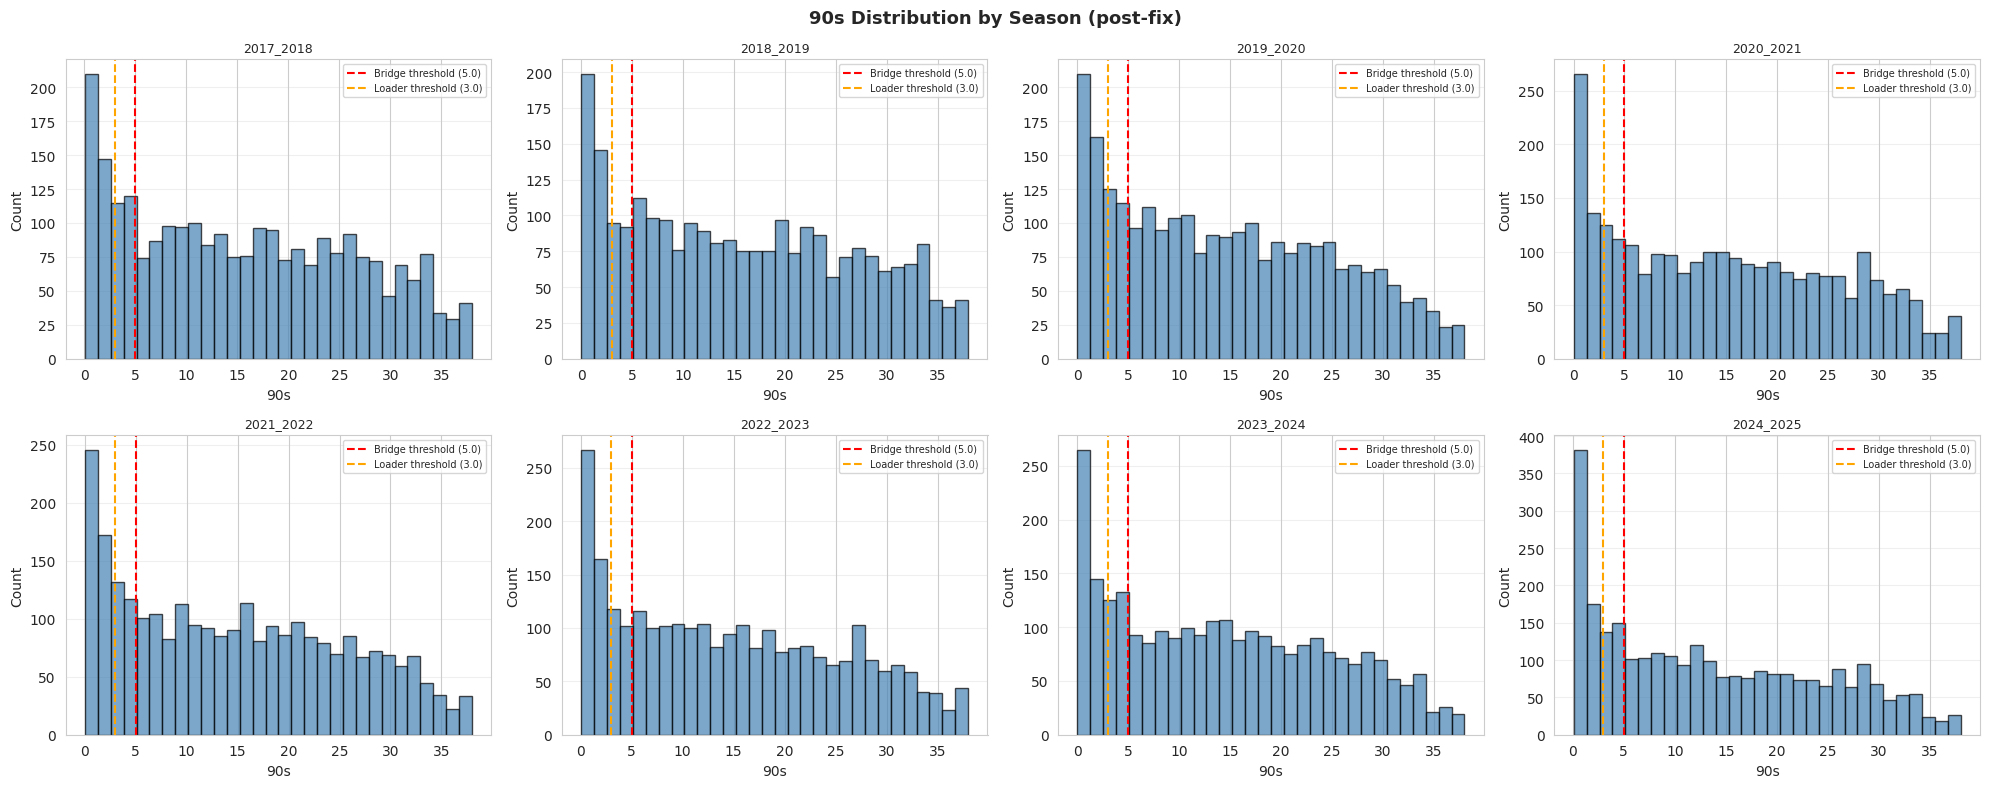

In [6]:
# ============================================================================
# CELL 6: 90s CONSISTENCY CHECK ACROSS SEASONS
# ============================================================================
# Verifies the 90s fix is consistent across historical and modern formats.
# Key check: per-90 rates should be comparable across seasons.

print("=" * 80)
print("90s CONSISTENCY CHECK")
print("=" * 80 + "\n")

EPS = 0.05

print(f"{'Season':<20} {'Format':<8} {'90s mean':>10} {'90s median':>12} "
      f"{'90s p5':>8} {'90s p95':>8} {'KP/90 mean':>12} {'PrgP/90 mean':>14}")
print("-" * 100)

for s, df in raw_data.items():
    is_mod = s in MODERN_SEASONS
    fmt    = 'modern' if is_mod else 'hist'
    nineties = pd.to_numeric(df['90s'], errors='coerce').fillna(0)
    kp  = pd.to_numeric(df['KP'], errors='coerce').fillna(0)
    pp  = pd.to_numeric(df['PrgP'], errors='coerce').fillna(0)

    mask = nineties >= MIN_90S_LOADER
    kp_rate = (kp[mask] / nineties[mask].clip(lower=6.0)).mean()
    pp_rate = (pp[mask] / nineties[mask].clip(lower=6.0)).mean()

    print(f"{s:<20} {fmt:<8} {nineties.mean():>10.2f} {nineties.median():>12.2f} "
          f"{np.percentile(nineties, 5):>8.2f} {np.percentile(nineties, 95):>8.2f} "
          f"{kp_rate:>12.4f} {pp_rate:>14.4f}")

print()
print("NOTE: KP/90 and PrgP/90 means should be consistent (~0.8–1.0 and ~3.0–4.0)")
print("      across all seasons. Large deviations indicate a unit mismatch.")

# Plot 90s distribution across seasons
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('90s Distribution by Season (post-fix)', fontsize=13, fontweight='bold')
for idx, (s, df) in enumerate(raw_data.items()):
    ax = axes[idx // 4, idx % 4]
    nineties = pd.to_numeric(df['90s'], errors='coerce').dropna()
    nineties = nineties[nineties > 0]
    ax.hist(nineties, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axvline(MIN_90S_BRIDGE, color='red', linestyle='--', linewidth=1.5,
               label=f'Bridge threshold ({MIN_90S_BRIDGE})')
    ax.axvline(MIN_90S_LOADER, color='orange', linestyle='--', linewidth=1.5,
               label=f'Loader threshold ({MIN_90S_LOADER})')
    ax.set_title(f'{s}', fontsize=9)
    ax.set_xlabel('90s')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

PER-90 RATE CONSISTENCY ACROSS SEASONS

               KP    PrgP    PrgC     SCA    TklW     Int     Clr  Blocks
2017_2018  0.8126  3.5070  1.6684  1.9549  1.0883  1.0477  2.0656  0.9781
2018_2019  0.8472  3.4570  1.7400  2.0257  0.9445  0.9701  1.9285  0.9908
2019_2020  0.8404  3.3666  1.6953  1.9974  0.8628  0.9342  1.6885  0.9112
2020_2021  0.7869  3.3163  1.5721  1.8582  0.7965  0.9913  1.5511  0.9229
2021_2022  0.8188  3.2364  1.5404  1.9336  0.8404  0.8772  1.5606  0.9565
2022_2023  0.8316  3.2647  1.5442  1.9603  0.8875  0.7966  1.5982  1.0146
2023_2024  0.8682  3.3090  1.5952  2.0438  0.9017  0.7226  1.7192  1.0241
2024_2025  0.8286  3.1805  1.5106  1.9578  0.8861  0.7060  2.0394  0.9482


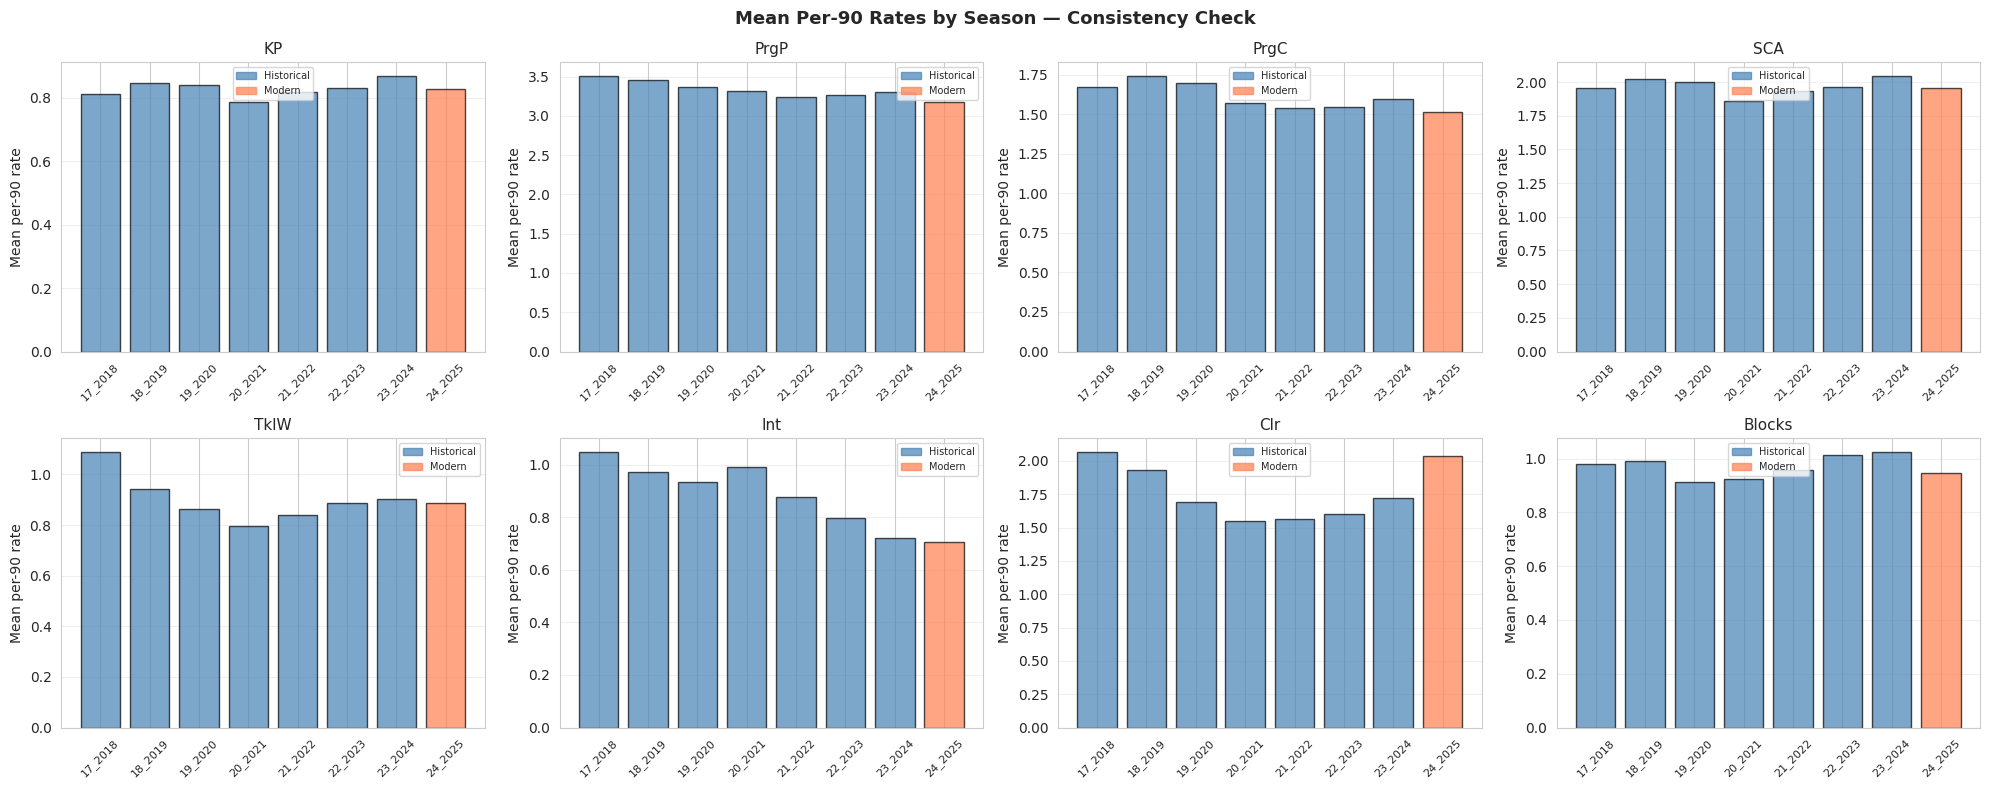

In [7]:
# ============================================================================
# CELL 7: PER-90 RATE CONSISTENCY ACROSS SEASONS
# ============================================================================
# For each stat, plots the mean per-90 rate by season to detect drifts
# or format inconsistencies that survived the 90s fix.

print("=" * 80)
print("PER-90 RATE CONSISTENCY ACROSS SEASONS")
print("=" * 80 + "\n")

all_stats = COMMON_STATS_ATT + COMMON_STATS_DEF
season_rates = {s: {} for s in ALL_SEASONS}

for s, df in raw_data.items():
    nineties = pd.to_numeric(df['90s'], errors='coerce').fillna(0)
    mask = nineties >= MIN_90S_LOADER
    for stat in all_stats:
        if stat in df.columns:
            vals = pd.to_numeric(df.loc[mask, stat], errors='coerce').fillna(0)
            n90  = nineties[mask].clip(lower=6.0)
            rate = (vals / n90).mean()
            season_rates[s][stat] = rate
        else:
            season_rates[s][stat] = np.nan

df_rates = pd.DataFrame(season_rates).T
print(df_rates.round(4).to_string())

# Plot per-90 rates over seasons
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Mean Per-90 Rates by Season — Consistency Check', fontsize=13, fontweight='bold')
for idx, stat in enumerate(all_stats):
    ax = axes[idx // 4, idx % 4]
    rates = [season_rates[s].get(stat, np.nan) for s in ALL_SEASONS]
    colors = ['steelblue' if s in HISTORICAL_SEASONS else 'coral' for s in ALL_SEASONS]
    ax.bar(range(len(ALL_SEASONS)), rates, color=colors, alpha=0.7, edgecolor='black')
    ax.set_xticks(range(len(ALL_SEASONS)))
    ax.set_xticklabels([s[-7:] for s in ALL_SEASONS], rotation=45, fontsize=8)
    ax.set_title(stat, fontsize=11)
    ax.set_ylabel('Mean per-90 rate')
    ax.grid(alpha=0.3, axis='y')
    # Add format legend
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color='steelblue', alpha=0.7, label='Historical'),
        Patch(color='coral', alpha=0.7, label='Modern'),
    ], fontsize=7)
plt.tight_layout()
plt.show()

In [8]:
# ============================================================================
# CELL 8: BRIDGE CONSTRUCTION & FILTER FUNNEL
# ============================================================================
# Builds all bridge pairs and tracks how many players drop at each filter step.
# This reveals which filters are binding and whether the bridge composition
# is stable across season pairs.

print("=" * 80)
print("BRIDGE CONSTRUCTION FILTER FUNNEL")
print("=" * 80 + "\n")

EPS = 0.05

def build_bridge_eda(df_s0, df_s1, valid_positions, stats_list, pair_label):
    """Build bridge with detailed filter tracking."""
    df_s0 = df_s0.sort_values('90s', ascending=False).drop_duplicates('Player_Key')
    df_s1 = df_s1.sort_values('90s', ascending=False).drop_duplicates('Player_Key')

    m = pd.merge(df_s0, df_s1, on='Player_Key', suffixes=('_src', '_trg'))

    funnel = {
        'pair':          pair_label,
        'merged':        len(m),
        'squad_change':  int((m['Squad_src'] != m['Squad_trg']).sum()),
        'to_pl':         int((m['Comp_trg'] == 'Premier League').sum()),
        'from_nonpl':    int((m['Comp_src'] != 'Premier League').sum()),
        'src_90s_ok':    int((m['90s_src'] >= MIN_90S_BRIDGE).sum()),
        'trg_90s_ok':    int((m['90s_trg'] >= MIN_90S_BRIDGE).sum()),
        'pos_ok':        int(m['Pos_Bucket_src'].isin(valid_positions).sum()),
    }

    valid = m[
        (m['Squad_src'] != m['Squad_trg']) &
        (m['Comp_src'] != 'Premier League') &
        (m['Comp_trg'] == 'Premier League') &
        (m['90s_src'] >= MIN_90S_BRIDGE) &
        (m['90s_trg'] >= MIN_90S_BRIDGE) &
        (m['Pos_Bucket_src'].isin(valid_positions))
    ].copy()

    funnel['valid'] = len(valid)

    rows = []
    for _, r in valid.iterrows():
        row = {
            'Player':        r['Player_src'],
            'League_origin': r['Comp_src'],
            'Age':           r['Age_src'],
            'Position':      r['Pos_Bucket_src'],
            'Team':          r['Squad_trg'],
            '90s_src':       r['90s_src'],
            '90s_trg':       r['90s_trg'],
            'Transfer_Season': pair_label,
        }
        for s in stats_list:
            src_val  = r.get(f'{s}_src', np.nan)
            trg_val  = r.get(f'{s}_trg', np.nan)
            n_src    = max(r['90s_src'], 6.0)
            n_trg    = max(r['90s_trg'], 6.0)
            src_rate = src_val / n_src
            trg_rate = trg_val / n_trg
            row[f'{s}_src']       = src_rate
            row[f'{s}_trg']       = trg_rate
            row[f'{s}_log_ratio'] = np.log((trg_rate + EPS) / (src_rate + EPS))
        rows.append(row)

    df_bridge = pd.DataFrame(rows).dropna(subset=['Age'])
    for s in stats_list:
        col = f'{s}_log_ratio'
        if col in df_bridge.columns:
            df_bridge[col] = df_bridge[col].replace([np.inf, -np.inf], np.nan)
    df_bridge = df_bridge.dropna(subset=[f'{s}_log_ratio' for s in stats_list])

    funnel['final'] = len(df_bridge)
    return df_bridge, funnel

# Build all pairs for ATT+MID and DEF
all_pairs = [(s, HISTORICAL_SEASONS[i+1]) for i, s in enumerate(HISTORICAL_SEASONS[:-1])]
all_pairs += [('2023_2024', '2024_2025')]

funnel_att, funnel_def = [], []
bridges_att, bridges_def = {}, {}

for s0, s1 in all_pairs:
    if s1 in MODERN_SEASONS:
        df_s0_att = raw_data[s0].copy()
        df_s1_att = raw_data[s1].copy()
        df_s0_def = raw_data[s0].copy()
        df_s1_def = raw_data[s1].copy()
    else:
        df_s0_att = raw_data[s0].copy()
        df_s1_att = raw_data[s1].copy()
        df_s0_def = raw_data[s0].copy()
        df_s1_def = raw_data[s1].copy()

    # Filter by position for DEF
    df_s0_def = df_s0_def[df_s0_def['Pos_Bucket'] == 'DEF']
    df_s1_def = df_s1_def[df_s1_def['Pos_Bucket'] == 'DEF']

    pair_label = f'{s0}_to_{s1}'

    bridge_att, f_att = build_bridge_eda(
        df_s0_att, df_s1_att,
        valid_positions=['FWD', 'MID'],
        stats_list=COMMON_STATS_ATT,
        pair_label=pair_label,
    )
    bridge_def, f_def = build_bridge_eda(
        df_s0_def, df_s1_def,
        valid_positions=['DEF'],
        stats_list=COMMON_STATS_DEF,
        pair_label=pair_label,
    )

    funnel_att.append(f_att)
    funnel_def.append(f_def)
    bridges_att[pair_label] = bridge_att
    bridges_def[pair_label] = bridge_def

df_funnel_att = pd.DataFrame(funnel_att)
df_funnel_def = pd.DataFrame(funnel_def)

print("=== ATT+MID Bridge Filter Funnel ===")
print(df_funnel_att.to_string(index=False))
print()
print("=== DEF Bridge Filter Funnel ===")
print(df_funnel_def.to_string(index=False))

BRIDGE CONSTRUCTION FILTER FUNNEL

=== ATT+MID Bridge Filter Funnel ===
                  pair  merged  squad_change  to_pl  from_nonpl  src_90s_ok  trg_90s_ok  pos_ok  valid  final
2017_2018_to_2018_2019    1736           485    366        1386        1555        1530     960     30     30
2018_2019_to_2019_2020    1717           465    342        1372        1536        1489     953     20     20
2019_2020_to_2020_2021    1803           405    365        1447        1583        1567     990     18     18
2020_2021_to_2021_2022    1815           404    363        1462        1596        1538    1002     22     22
2021_2022_to_2022_2023    1772           507    372        1419        1556        1517     975     27     27
2022_2023_to_2023_2024    1746           502    372        1381        1533        1473     945     27     27
2023_2024_to_2024_2025    1769           496    372        1392        1522        1475     969     18     18

=== DEF Bridge Filter Funnel ===
              

BRIDGE COMPOSITION ANALYSIS

--- ATT+MID Training (n=117) ---
  League distribution:
League_origin
La Liga       37
Ligue 1       32
Bundesliga    31
Serie A       17
  Position distribution:
Position
MID    69
FWD    48
  Age: mean=23.4  std=3.4  min=18  max=35
  90s_src: mean=19.61  median=19.91  min=5.11  max=36.93
  Unique teams: 26

--- ATT+MID Test (n=45) ---
  League distribution:
League_origin
Ligue 1       13
La Liga       12
Bundesliga    10
Serie A       10
  Position distribution:
Position
MID    26
FWD    19
  Age: mean=23.8  std=3.7  min=17  max=32
  90s_src: mean=18.42  median=17.76  min=5.31  max=33.27
  Unique teams: 20

--- DEF Training (n=71) ---
  League distribution:
League_origin
Ligue 1       25
La Liga       18
Serie A       16
Bundesliga    12
  Position distribution:
Position
DEF    71
  Age: mean=24.2  std=3.8  min=18  max=35
  90s_src: mean=22.74  median=23.30  min=5.41  max=37.00
  Unique teams: 22

--- DEF Test (n=35) ---
  League distribution:
League_orig

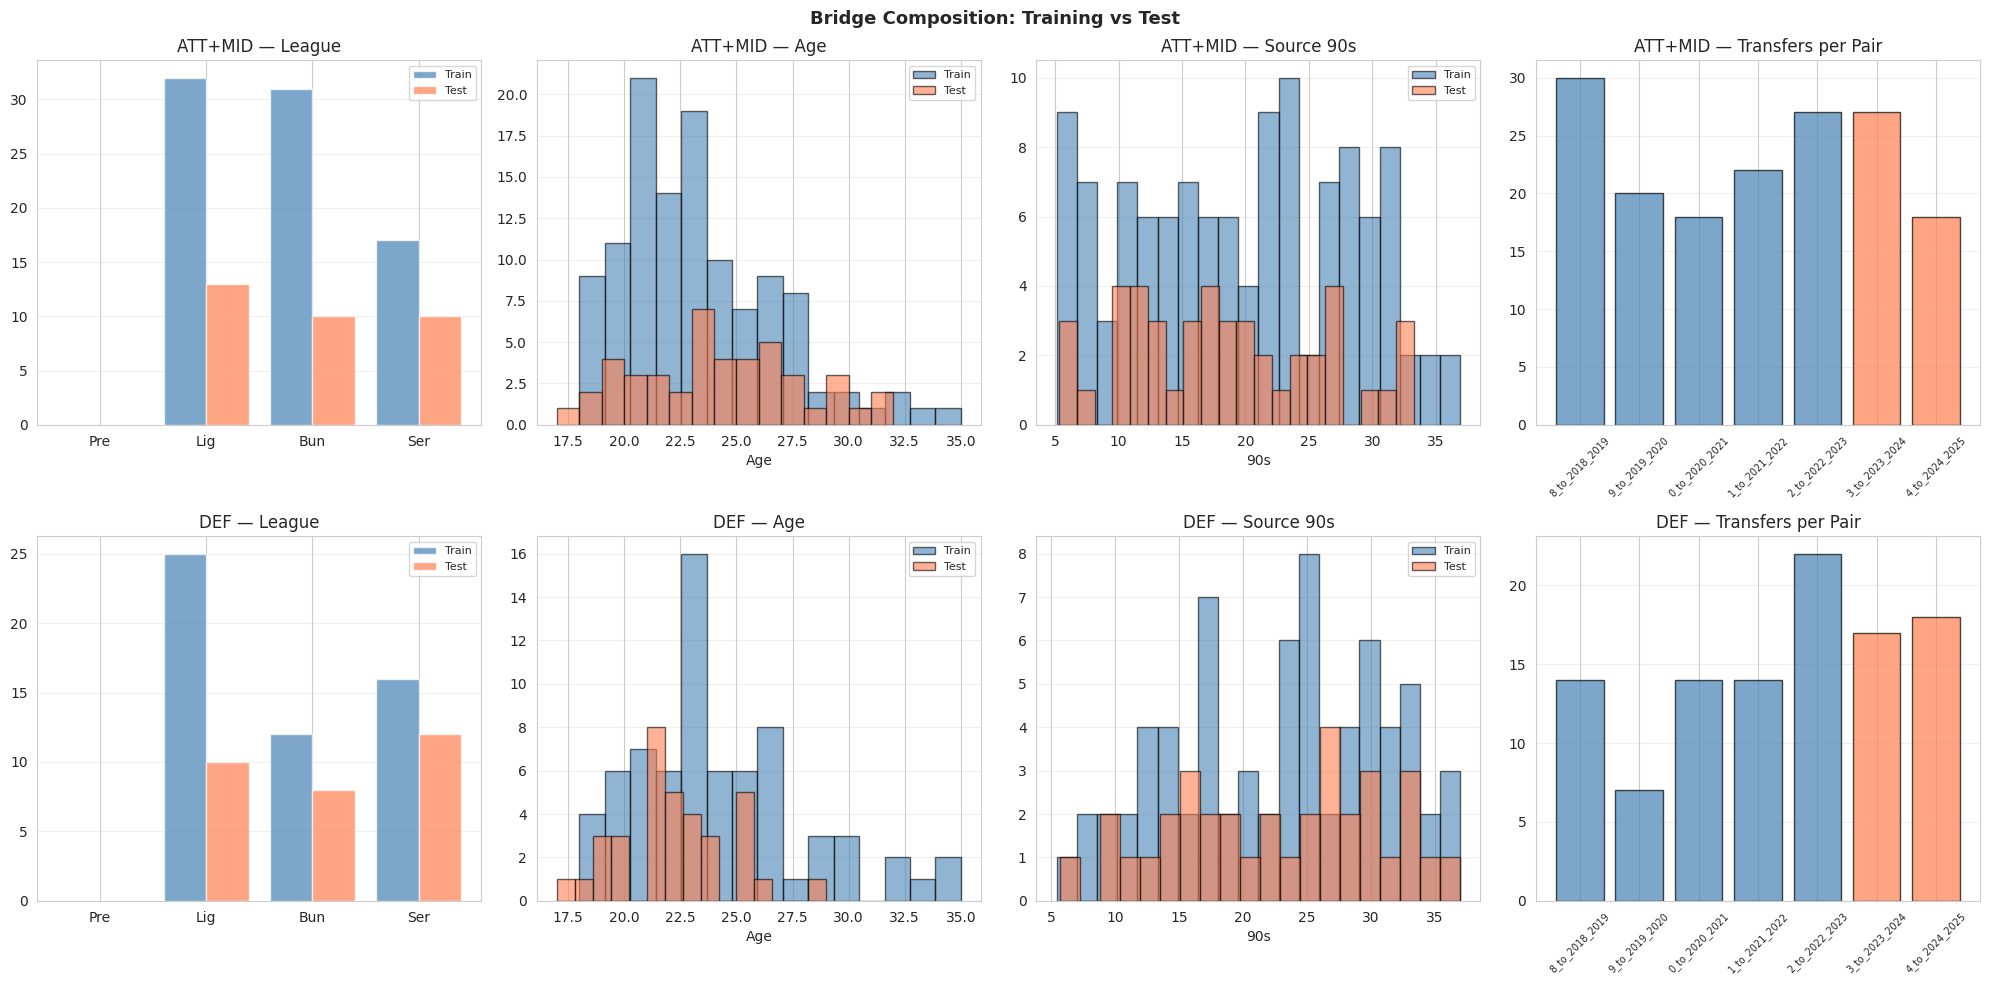

In [9]:
# ============================================================================
# CELL 9: BRIDGE COMPOSITION — LEAGUE, POSITION, AGE, MINUTES
# ============================================================================

print("=" * 80)
print("BRIDGE COMPOSITION ANALYSIS")
print("=" * 80 + "\n")

# Combine training bridges
train_att = pd.concat(
    [bridges_att[p] for p in TRAIN_PAIRS if p in bridges_att],
    ignore_index=True
)
train_def = pd.concat(
    [bridges_def[p] for p in TRAIN_PAIRS if p in bridges_def],
    ignore_index=True
)
test_att = pd.concat(
    [bridges_att[p] for p in TEST_PAIRS if p in bridges_att],
    ignore_index=True
)
test_def = pd.concat(
    [bridges_def[p] for p in TEST_PAIRS if p in bridges_def],
    ignore_index=True
)

for label, df in [('ATT+MID Training', train_att), ('ATT+MID Test', test_att),
                   ('DEF Training', train_def),     ('DEF Test', test_def)]:
    print(f"--- {label} (n={len(df)}) ---")
    print(f"  League distribution:\n{df['League_origin'].value_counts().to_string()}")
    print(f"  Position distribution:\n{df['Position'].value_counts().to_string()}")
    print(f"  Age: mean={df['Age'].mean():.1f}  std={df['Age'].std():.1f}  "
          f"min={df['Age'].min():.0f}  max={df['Age'].max():.0f}")
    print(f"  90s_src: mean={df['90s_src'].mean():.2f}  median={df['90s_src'].median():.2f}  "
          f"min={df['90s_src'].min():.2f}  max={df['90s_src'].max():.2f}")
    print(f"  Unique teams: {df['Team'].nunique()}")
    print()

# Plots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Bridge Composition: Training vs Test', fontsize=13, fontweight='bold')

for row_idx, (train_df, test_df, bridge_label) in enumerate([
    (train_att, test_att, 'ATT+MID'),
    (train_def, test_def, 'DEF'),
]):
    # League distribution
    ax = axes[row_idx, 0]
    leagues = VALID_LEAGUES[:-1]  # exclude PL
    tr_counts = [len(train_df[train_df['League_origin'] == l]) for l in leagues]
    te_counts  = [len(test_df[test_df['League_origin'] == l]) for l in leagues]
    x = np.arange(len(leagues))
    ax.bar(x - 0.2, tr_counts, 0.4, label='Train', color='steelblue', alpha=0.7)
    ax.bar(x + 0.2, te_counts,  0.4, label='Test',  color='coral',     alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels([l[:3] for l in leagues])
    ax.set_title(f'{bridge_label} — League')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis='y')

    # Age distribution
    ax = axes[row_idx, 1]
    ax.hist(train_df['Age'], bins=15, alpha=0.6, color='steelblue', label='Train', edgecolor='black')
    ax.hist(test_df['Age'],  bins=15, alpha=0.6, color='coral',     label='Test',  edgecolor='black')
    ax.set_title(f'{bridge_label} — Age')
    ax.set_xlabel('Age')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis='y')

    # 90s_src distribution
    ax = axes[row_idx, 2]
    ax.hist(train_df['90s_src'], bins=20, alpha=0.6, color='steelblue', label='Train', edgecolor='black')
    ax.hist(test_df['90s_src'],  bins=20, alpha=0.6, color='coral',     label='Test',  edgecolor='black')
    ax.set_title(f'{bridge_label} — Source 90s')
    ax.set_xlabel('90s')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis='y')

    # Transfers per season pair
    ax = axes[row_idx, 3]
    all_pairs_labels = TRAIN_PAIRS + TEST_PAIRS
    combined = pd.concat([train_df, test_df], ignore_index=True)
    counts = combined.groupby('Transfer_Season').size().reindex(all_pairs_labels, fill_value=0)
    colors = ['steelblue' if p in TRAIN_PAIRS else 'coral' for p in all_pairs_labels]
    ax.bar(range(len(all_pairs_labels)), counts.values, color=colors, alpha=0.7, edgecolor='black')
    ax.set_xticks(range(len(all_pairs_labels)))
    ax.set_xticklabels([p[-14:] for p in all_pairs_labels], rotation=45, fontsize=7)
    ax.set_title(f'{bridge_label} — Transfers per Pair')
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

LOG-RATIO DISTRIBUTIONS — ALL STATS, ALL PAIRS


=== ATT+MID ===

  Pair                               N   KP_mean  KP_std  PrgP_mean  PrgP_std  PrgC_mean  PrgC_std  SCA_mean  SCA_std
  -------------------------------------------------------------------------------------------------------------------
  2017_2018_to_2018_2019            30   -0.2163    0.4730   -0.1200    0.3110   -0.1499    0.5146   -0.0971    0.3545
  2018_2019_to_2019_2020            20   -0.1100    0.4261   -0.1478    0.3913   -0.2605    0.5135   -0.1208    0.3870
  2019_2020_to_2020_2021            18    0.0518    0.4297   -0.0077    0.2693   -0.2460    0.3553    0.0094    0.3520
  2020_2021_to_2021_2022            22   -0.0507    0.4812   -0.1378    0.5116   -0.1309    0.3352   -0.0694    0.3171
  2021_2022_to_2022_2023            27   -0.2098    0.5717   -0.2194    0.4316   -0.3989    0.4999   -0.2046    0.4142
  2022_2023_to_2023_2024            27   -0.1651    0.5022    0.0016    0.5271   -0.0667    0.4646   -0

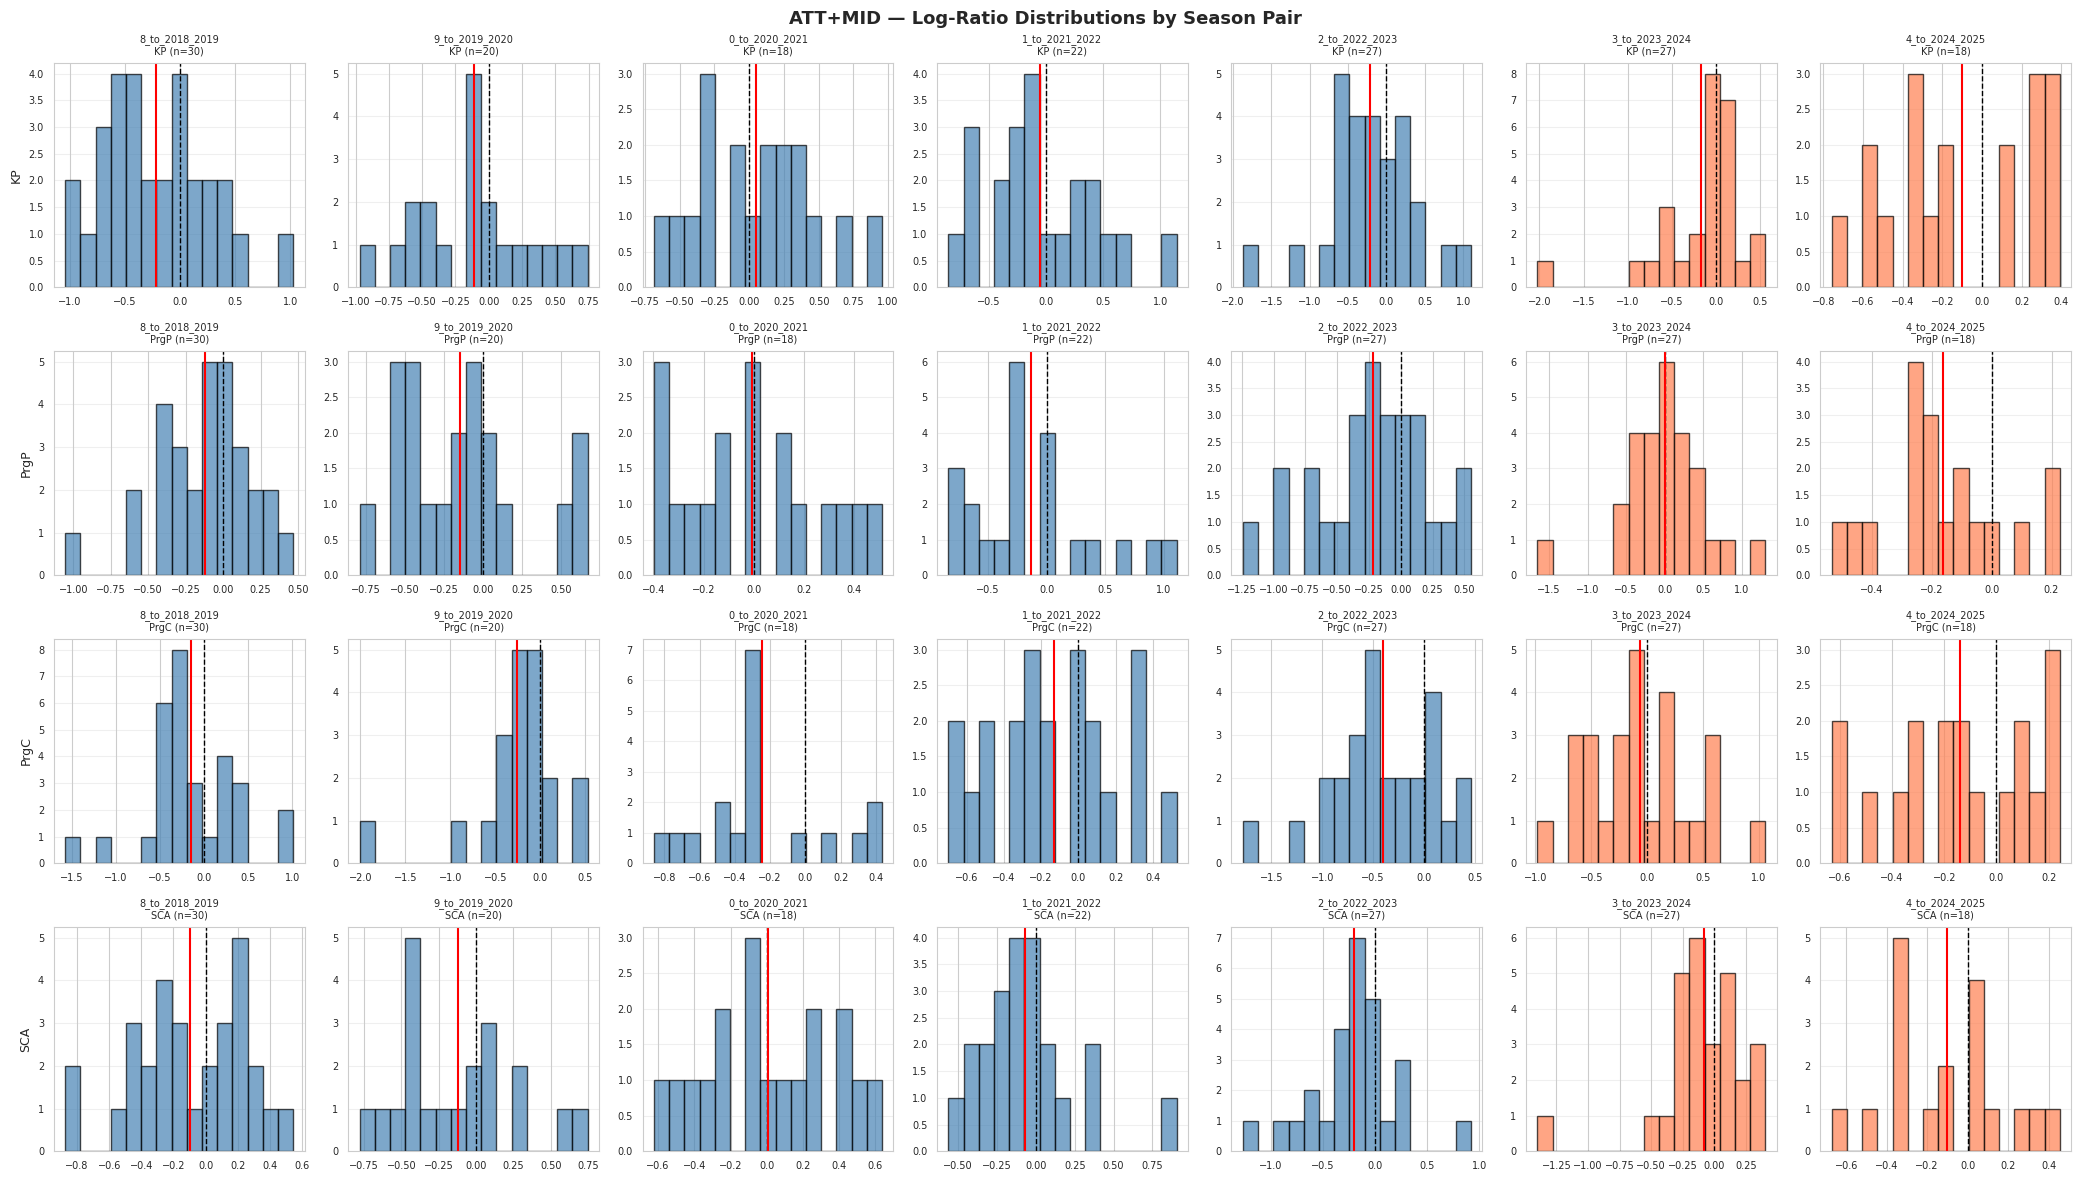

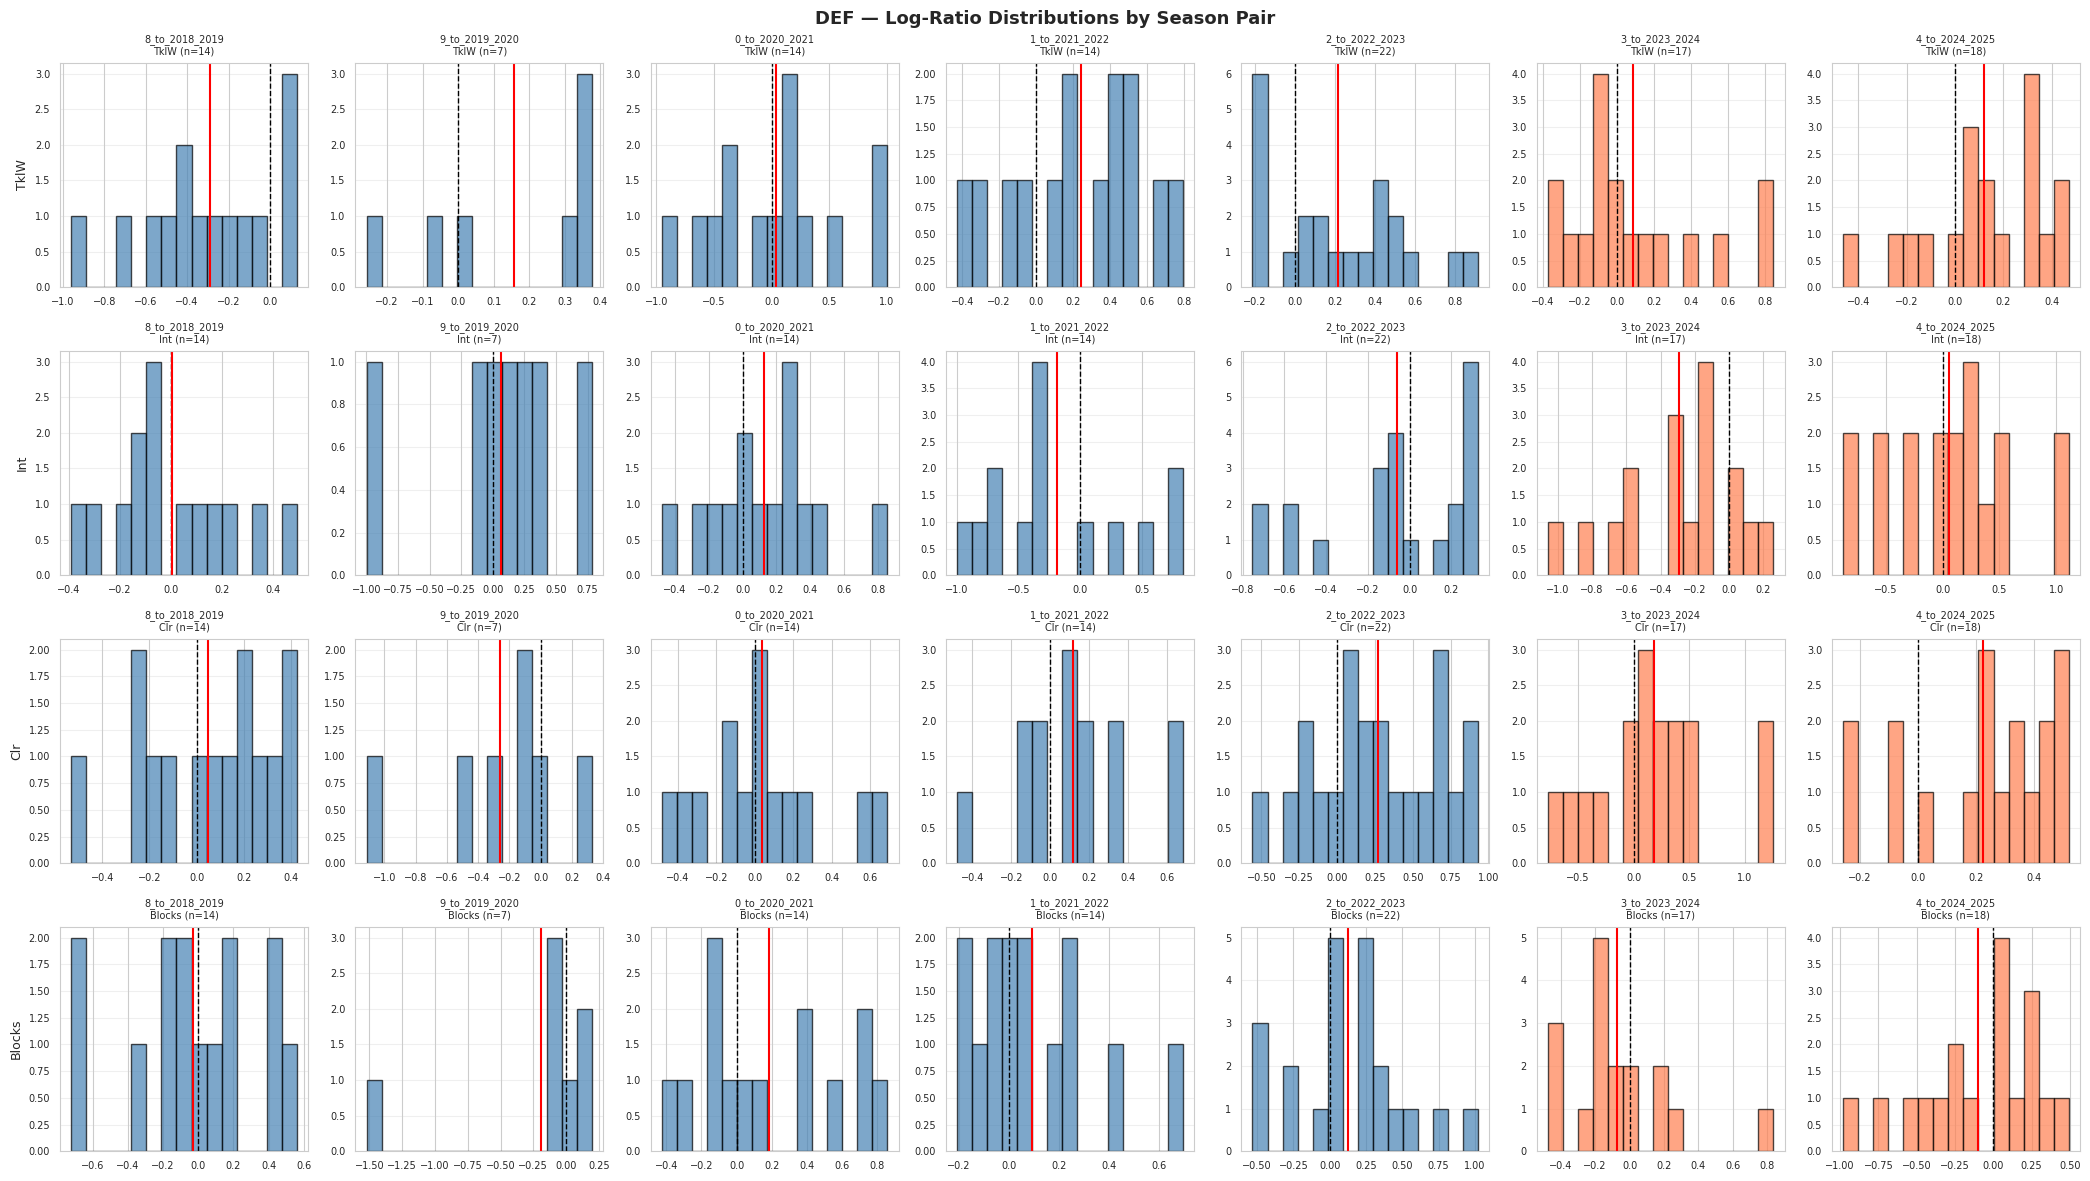

In [10]:
# ============================================================================
# CELL 10: LOG-RATIO DISTRIBUTIONS — ALL STATS, ALL PAIRS
# ============================================================================
# Full distributional analysis of log-ratios per stat per season pair.
# Checks for: outliers, skewness, distributional drift across seasons.

print("=" * 80)
print("LOG-RATIO DISTRIBUTIONS — ALL STATS, ALL PAIRS")
print("=" * 80 + "\n")

for bridge_label, stats_list, all_bridges in [
    ('ATT+MID', COMMON_STATS_ATT, bridges_att),
    ('DEF',     COMMON_STATS_DEF, bridges_def),
]:
    print(f"\n=== {bridge_label} ===\n")
    print(f"  {'Pair':<30} {'N':>5} ", end='')
    for s in stats_list:
        print(f"  {s}_mean  {s}_std", end='')
    print()
    print("  " + "-" * (35 + 20 * len(stats_list)))

    for pair_label, df in all_bridges.items():
        if df.empty:
            continue
        is_test = any(tp in pair_label for tp in TEST_PAIRS)
        marker  = ' [TEST]' if is_test else ''
        print(f"  {pair_label:<30} {len(df):>5}", end='')
        for s in stats_list:
            vals = df[f'{s}_log_ratio'].values
            print(f"  {vals.mean():>8.4f}  {vals.std():>8.4f}", end='')
        print(marker)

    print()

# Plot log-ratio distributions per stat, split by season pair
for bridge_label, stats_list, all_bridges in [
    ('ATT+MID', COMMON_STATS_ATT, bridges_att),
    ('DEF',     COMMON_STATS_DEF, bridges_def),
]:
    n_stats = len(stats_list)
    n_pairs = len(all_bridges)
    fig, axes = plt.subplots(n_stats, n_pairs, figsize=(n_pairs * 3, n_stats * 3))
    fig.suptitle(f'{bridge_label} — Log-Ratio Distributions by Season Pair',
                 fontsize=13, fontweight='bold')

    for col_idx, (pair_label, df) in enumerate(all_bridges.items()):
        is_test = any(tp in pair_label for tp in TEST_PAIRS)
        for row_idx, s in enumerate(stats_list):
            ax = axes[row_idx, col_idx]
            if not df.empty and f'{s}_log_ratio' in df.columns:
                vals = df[f'{s}_log_ratio'].dropna().values
                color = 'coral' if is_test else 'steelblue'
                ax.hist(vals, bins=15, color=color, alpha=0.7, edgecolor='black')
                ax.axvline(0, color='black', linestyle='--', linewidth=1)
                ax.axvline(vals.mean(), color='red', linestyle='-', linewidth=1.5)
                ax.set_title(f'{pair_label[-14:]}\n{s} (n={len(vals)})', fontsize=7)
            else:
                ax.text(0.5, 0.5, 'empty', ha='center', va='center')
            if col_idx == 0:
                ax.set_ylabel(s, fontsize=9)
            ax.tick_params(labelsize=7)
            ax.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

In [11]:
# ============================================================================
# CELL 11: OUTLIER DETECTION IN LOG-RATIOS
# ============================================================================
# Identifies extreme log-ratio values (|z| > 3) that may be data errors,
# unusual transfers, or positional role changes.

print("=" * 80)
print("OUTLIER DETECTION IN LOG-RATIOS")
print("=" * 80 + "\n")

Z_THRESHOLD = 3.0

for bridge_label, stats_list, all_bridges in [
    ('ATT+MID', COMMON_STATS_ATT, bridges_att),
    ('DEF',     COMMON_STATS_DEF, bridges_def),
]:
    combined = pd.concat(list(all_bridges.values()), ignore_index=True)
    if combined.empty:
        continue

    print(f"=== {bridge_label} Outliers (|z| > {Z_THRESHOLD}) ===\n")

    for s in stats_list:
        col  = f'{s}_log_ratio'
        vals = combined[col].dropna()
        mean_s, std_s = vals.mean(), vals.std()
        z_scores = (combined[col] - mean_s) / (std_s + 1e-8)
        outliers = combined[z_scores.abs() > Z_THRESHOLD][
            ['Player', 'Transfer_Season', 'League_origin', 'Age', col,
             f'{s}_src', f'{s}_trg', '90s_src']
        ].copy()
        outliers['z_score'] = z_scores[z_scores.abs() > Z_THRESHOLD].values

        if not outliers.empty:
            print(f"  {s} — {len(outliers)} outlier(s):")
            print(outliers.sort_values('z_score').to_string(index=False))
        else:
            print(f"  {s} — No outliers found")
        print()

OUTLIER DETECTION IN LOG-RATIOS

=== ATT+MID Outliers (|z| > 3.0) ===

  KP — 2 outlier(s):
      Player        Transfer_Season League_origin  Age  KP_log_ratio   KP_src   KP_trg   90s_src   z_score
Aaron Ramsey 2022_2023_to_2023_2024       Ligue 1   31     -2.024646 1.590909 0.166667 17.600000 -3.902960
Orel Mangala 2021_2022_to_2022_2023    Bundesliga   23     -1.872672 1.408527 0.174194 20.588889 -3.590145

  PrgP — 2 outlier(s):
        Player        Transfer_Season League_origin  Age  PrgP_log_ratio  PrgP_src  PrgP_trg   90s_src   z_score
  Aaron Ramsey 2022_2023_to_2023_2024       Ligue 1   31       -1.650847  7.159091  1.333333 17.600000 -3.737405
Arnaut Danjuma 2022_2023_to_2023_2024       La Liga   25        1.303393  0.333333  1.361345  5.322222  3.448636

  PrgC — 3 outlier(s):
        Player        Transfer_Season League_origin  Age  PrgC_log_ratio  PrgC_src  PrgC_trg   90s_src   z_score
Nabil Bentaleb 2018_2019_to_2019_2020    Bundesliga   23       -2.008796  2.109375  0.2

TRAINING vs TEST DISTRIBUTIONAL SHIFT

=== ATT+MID ===
  Train n=117, Test n=45

  Stat       Tr mean   Te mean   Tr std   Te std   KS stat     KS p    Lev p   t-test p   Shift?
  -----------------------------------------------------------------------------------------------
  KP         -0.1242   -0.1395   0.4954   0.4541    0.1197   0.6932   0.2910     0.8533       no
  PrgP       -0.1337   -0.0640   0.3982   0.4347    0.1453   0.4541   0.8955     0.3570       no
  PrgC       -0.2375   -0.0959   0.4705   0.4001    0.2393   0.0403   0.5880     0.0604    ⚠ YES
  SCA        -0.1044   -0.0928   0.3741   0.3228    0.1538   0.3840   0.1716     0.8474       no

=== DEF ===
  Train n=71, Test n=35

  Stat       Tr mean   Te mean   Tr std   Te std   KS stat     KS p    Lev p   t-test p   Shift?
  -----------------------------------------------------------------------------------------------
  TklW        0.0805    0.1046   0.4242   0.3046    0.1404   0.6668   0.0555     0.7411       no
  Int 

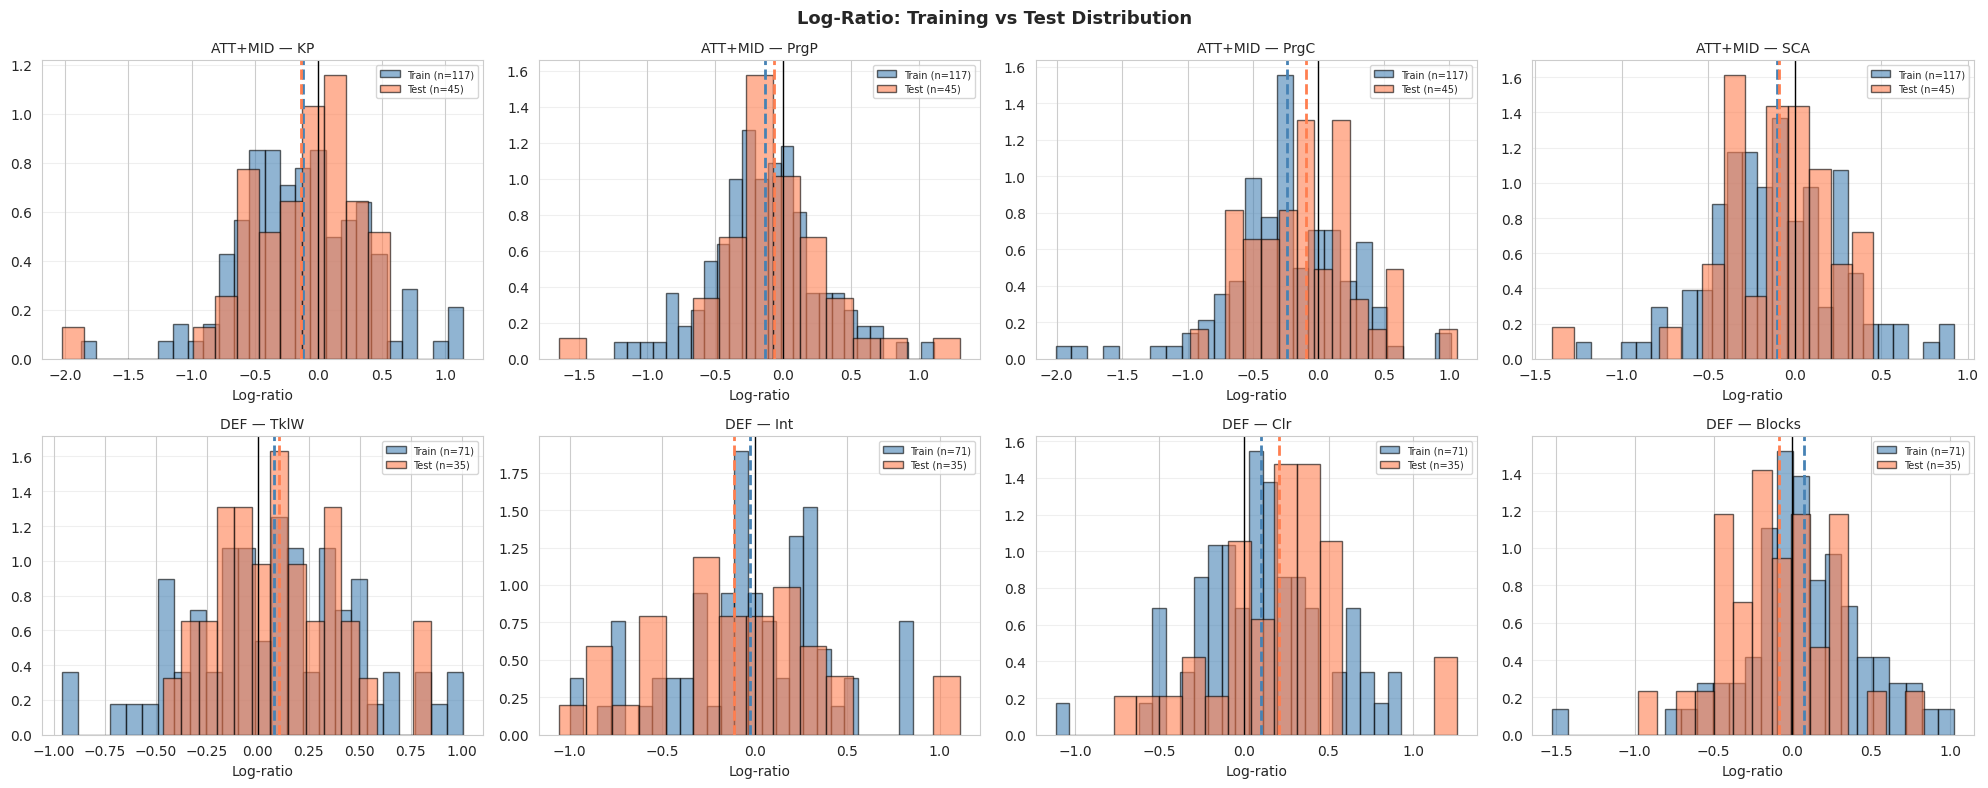

In [12]:
# ============================================================================
# CELL 12: TRAINING vs TEST DISTRIBUTIONAL SHIFT
# ============================================================================
# Direct statistical comparison of training and test log-ratio distributions.
# Tests: KS test, Levene's test for variance equality, mean shift.

print("=" * 80)
print("TRAINING vs TEST DISTRIBUTIONAL SHIFT")
print("=" * 80 + "\n")

from scipy.stats import ks_2samp, levene, ttest_ind

for bridge_label, stats_list, all_bridges in [
    ('ATT+MID', COMMON_STATS_ATT, bridges_att),
    ('DEF',     COMMON_STATS_DEF, bridges_def),
]:
    train_df = pd.concat(
        [all_bridges[p] for p in TRAIN_PAIRS if p in all_bridges and not all_bridges[p].empty],
        ignore_index=True
    )
    test_df = pd.concat(
        [all_bridges[p] for p in TEST_PAIRS if p in all_bridges and not all_bridges[p].empty],
        ignore_index=True
    )

    print(f"=== {bridge_label} ===")
    print(f"  Train n={len(train_df)}, Test n={len(test_df)}\n")
    print(f"  {'Stat':<8} {'Tr mean':>9} {'Te mean':>9} {'Tr std':>8} {'Te std':>8} "
          f"{'KS stat':>9} {'KS p':>8} {'Lev p':>8} {'t-test p':>10} {'Shift?':>8}")
    print("  " + "-" * 95)

    for s in stats_list:
        col = f'{s}_log_ratio'
        tr  = train_df[col].dropna().values
        te  = test_df[col].dropna().values

        ks_stat, ks_p   = ks_2samp(tr, te)
        _, lev_p         = levene(tr, te)
        _, tt_p          = ttest_ind(tr, te, equal_var=False)

        shift = '⚠ YES' if ks_p < 0.05 else 'no'
        print(f"  {s:<8} {tr.mean():>9.4f} {te.mean():>9.4f} {tr.std():>8.4f} {te.std():>8.4f} "
              f"{ks_stat:>9.4f} {ks_p:>8.4f} {lev_p:>8.4f} {tt_p:>10.4f} {shift:>8}")
    print()

# Visualise the shift
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Log-Ratio: Training vs Test Distribution', fontsize=13, fontweight='bold')

for row_idx, (bridge_label, stats_list, all_bridges) in enumerate([
    ('ATT+MID', COMMON_STATS_ATT, bridges_att),
    ('DEF',     COMMON_STATS_DEF, bridges_def),
]):
    train_df = pd.concat(
        [all_bridges[p] for p in TRAIN_PAIRS if p in all_bridges and not all_bridges[p].empty],
        ignore_index=True
    )
    test_df = pd.concat(
        [all_bridges[p] for p in TEST_PAIRS if p in all_bridges and not all_bridges[p].empty],
        ignore_index=True
    )
    for col_idx, s in enumerate(stats_list):
        ax = axes[row_idx, col_idx]
        tr_vals = train_df[f'{s}_log_ratio'].dropna().values
        te_vals = test_df[f'{s}_log_ratio'].dropna().values
        ax.hist(tr_vals, bins=25, alpha=0.6, color='steelblue', label=f'Train (n={len(tr_vals)})',
                edgecolor='black', density=True)
        ax.hist(te_vals, bins=15, alpha=0.6, color='coral',     label=f'Test (n={len(te_vals)})',
                edgecolor='black', density=True)
        ax.axvline(tr_vals.mean(), color='steelblue', linestyle='--', linewidth=2)
        ax.axvline(te_vals.mean(), color='coral',     linestyle='--', linewidth=2)
        ax.axvline(0, color='black', linestyle='-', linewidth=1)
        ax.set_title(f'{bridge_label} — {s}', fontsize=10)
        ax.set_xlabel('Log-ratio')
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

CORRELATION STRUCTURE OF LOG-RATIOS (Training Bridge)

=== ATT+MID Pearson Correlation Matrix ===
                KP_log_ratio  PrgP_log_ratio  PrgC_log_ratio  SCA_log_ratio
KP_log_ratio           1.000           0.387           0.211          0.810
PrgP_log_ratio         0.387           1.000           0.345          0.509
PrgC_log_ratio         0.211           0.345           1.000          0.343
SCA_log_ratio          0.810           0.509           0.343          1.000

=== ATT+MID Spearman Correlation Matrix ===
                KP_log_ratio  PrgP_log_ratio  PrgC_log_ratio  SCA_log_ratio
KP_log_ratio           1.000           0.370           0.188          0.796
PrgP_log_ratio         0.370           1.000           0.242          0.467
PrgC_log_ratio         0.188           0.242           1.000          0.255
SCA_log_ratio          0.796           0.467           0.255          1.000

=== DEF Pearson Correlation Matrix ===
                  TklW_log_ratio  Int_log_ratio  Clr_log_

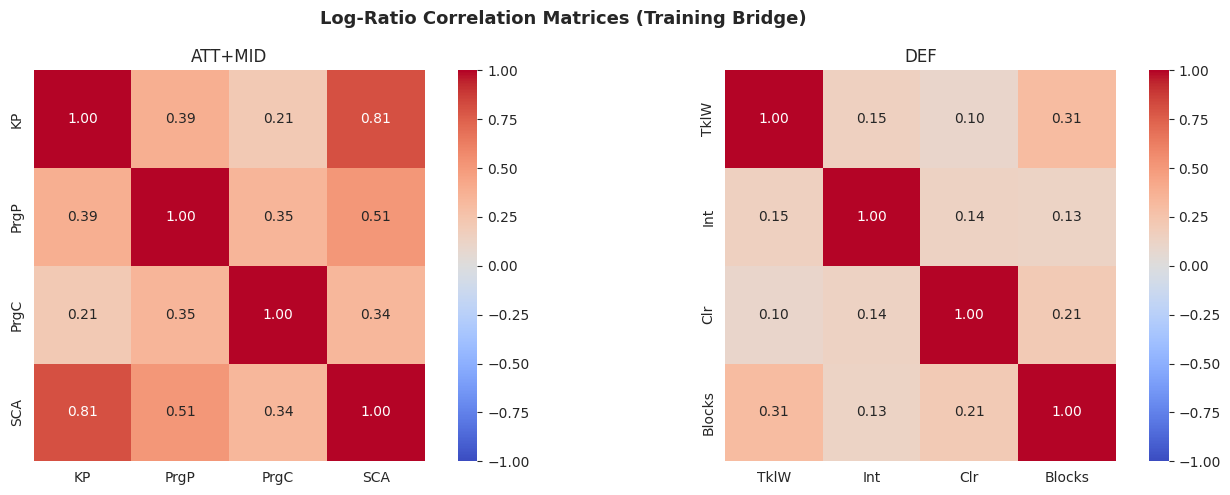

In [13]:
# ============================================================================
# CELL 13: CORRELATION STRUCTURE OF STATS
# ============================================================================
# Checks the correlation matrix of log-ratios within the training bridge.
# High correlations validate the joint LKJ covariance model assumption.
# Low or negative correlations may indicate problematic joint modelling.

print("=" * 80)
print("CORRELATION STRUCTURE OF LOG-RATIOS (Training Bridge)")
print("=" * 80 + "\n")

for bridge_label, stats_list, all_bridges in [
    ('ATT+MID', COMMON_STATS_ATT, bridges_att),
    ('DEF',     COMMON_STATS_DEF, bridges_def),
]:
    train_df = pd.concat(
        [all_bridges[p] for p in TRAIN_PAIRS if p in all_bridges and not all_bridges[p].empty],
        ignore_index=True
    )
    lr_cols  = [f'{s}_log_ratio' for s in stats_list]
    corr_mat = train_df[lr_cols].corr()

    print(f"=== {bridge_label} Pearson Correlation Matrix ===")
    print(corr_mat.round(3).to_string())
    print()

    # Spearman
    spear_mat = train_df[lr_cols].corr(method='spearman')
    print(f"=== {bridge_label} Spearman Correlation Matrix ===")
    print(spear_mat.round(3).to_string())
    print()

# Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Log-Ratio Correlation Matrices (Training Bridge)', fontsize=13, fontweight='bold')

for ax, bridge_label, stats_list, all_bridges in [
    (axes[0], 'ATT+MID', COMMON_STATS_ATT, bridges_att),
    (axes[1], 'DEF',     COMMON_STATS_DEF, bridges_def),
]:
    train_df = pd.concat(
        [all_bridges[p] for p in TRAIN_PAIRS if p in all_bridges and not all_bridges[p].empty],
        ignore_index=True
    )
    lr_cols  = [f'{s}_log_ratio' for s in stats_list]
    corr_mat = train_df[lr_cols].corr()
    corr_mat.columns = stats_list
    corr_mat.index   = stats_list
    sns.heatmap(corr_mat, ax=ax, annot=True, fmt='.2f', cmap='coolwarm',
                vmin=-1, vmax=1, center=0, square=True)
    ax.set_title(f'{bridge_label}', fontsize=12)

plt.tight_layout()
plt.show()

In [14]:
# ============================================================================
# CELL 14: SOURCE vs TARGET RATE CONSISTENCY CHECK
# ============================================================================
# For each stat, checks whether src_rate and trg_rate are on the same scale
# across all season pairs. This directly catches any remaining unit mismatches.

print("=" * 80)
print("SOURCE vs TARGET RATE CONSISTENCY")
print("=" * 80 + "\n")

for bridge_label, stats_list, all_bridges in [
    ('ATT+MID', COMMON_STATS_ATT, bridges_att),
    ('DEF',     COMMON_STATS_DEF, bridges_def),
]:
    print(f"=== {bridge_label} ===")
    print(f"  {'Pair':<30} {'N':>5} ", end='')
    for s in stats_list:
        print(f"  {s}_src  {s}_trg  ratio", end='')
    print()
    print("  " + "-" * (40 + 25 * len(stats_list)))

    for pair_label, df in all_bridges.items():
        if df.empty:
            continue
        is_test = any(tp in pair_label for tp in TEST_PAIRS)
        print(f"  {pair_label:<30} {len(df):>5}", end='')
        for s in stats_list:
            src = df[f'{s}_src'].mean()
            trg = df[f'{s}_trg'].mean()
            ratio = trg / src if src > 0 else float('nan')
            flag = ' ⚠' if abs(ratio - 1.0) > 0.5 else ''
            print(f"  {src:>7.4f}  {trg:>7.4f}  {ratio:>5.2f}{flag}", end='')
        print(' [TEST]' if is_test else '')
    print()

print("NOTE: src/trg ratio should be near 1.0 for all pairs.")
print("      Large deviations (>1.5x or <0.5x) indicate unit mismatches.")

SOURCE vs TARGET RATE CONSISTENCY

=== ATT+MID ===
  Pair                               N   KP_src  KP_trg  ratio  PrgP_src  PrgP_trg  ratio  PrgC_src  PrgC_trg  ratio  SCA_src  SCA_trg  ratio
  --------------------------------------------------------------------------------------------------------------------------------------------
  2017_2018_to_2018_2019            30   1.3341   1.0917   0.82   4.7006   4.1663   0.89   2.7599   2.3864   0.86   3.0516   2.7767   0.91
  2018_2019_to_2019_2020            20   1.4408   1.2609   0.88   4.7733   4.1151   0.86   3.1611   2.7043   0.86   3.4635   3.0005   0.87
  2019_2020_to_2020_2021            18   1.2184   1.2500   1.03   4.1574   4.0282   0.97   2.4136   1.8751   0.78   2.8694   2.8211   0.98
  2020_2021_to_2021_2022            22   1.1992   1.1262   0.94   3.8356   3.2397   0.84   2.5999   2.2846   0.88   2.8726   2.6770   0.93
  2021_2022_to_2022_2023            27   1.0566   0.8630   0.82   3.9977   3.2142   0.80   1.8768   1.3404  

SEASON-BY-SEASON TREND ANALYSIS

=== ATT+MID — Temporal Trend in Log-Ratio Means ===

  Stat          Slope       R²    p-value     Trend?
  --------------------------------------------------
  KP           0.0072   0.0102     0.8715         no
  PrgP        -0.0189   0.1525     0.5158         no
  PrgC        -0.0368   0.2971     0.3421         no
  SCA         -0.0164   0.1104     0.5848         no

=== DEF — Temporal Trend in Log-Ratio Means ===

  Stat          Slope       R²    p-value     Trend?
  --------------------------------------------------
  TklW         0.1098   0.6357     0.1062         no
  Int         -0.0378   0.2467     0.3947         no
  Clr          0.0818   0.4471     0.2172         no
  Blocks       0.0599   0.4002     0.2521         no



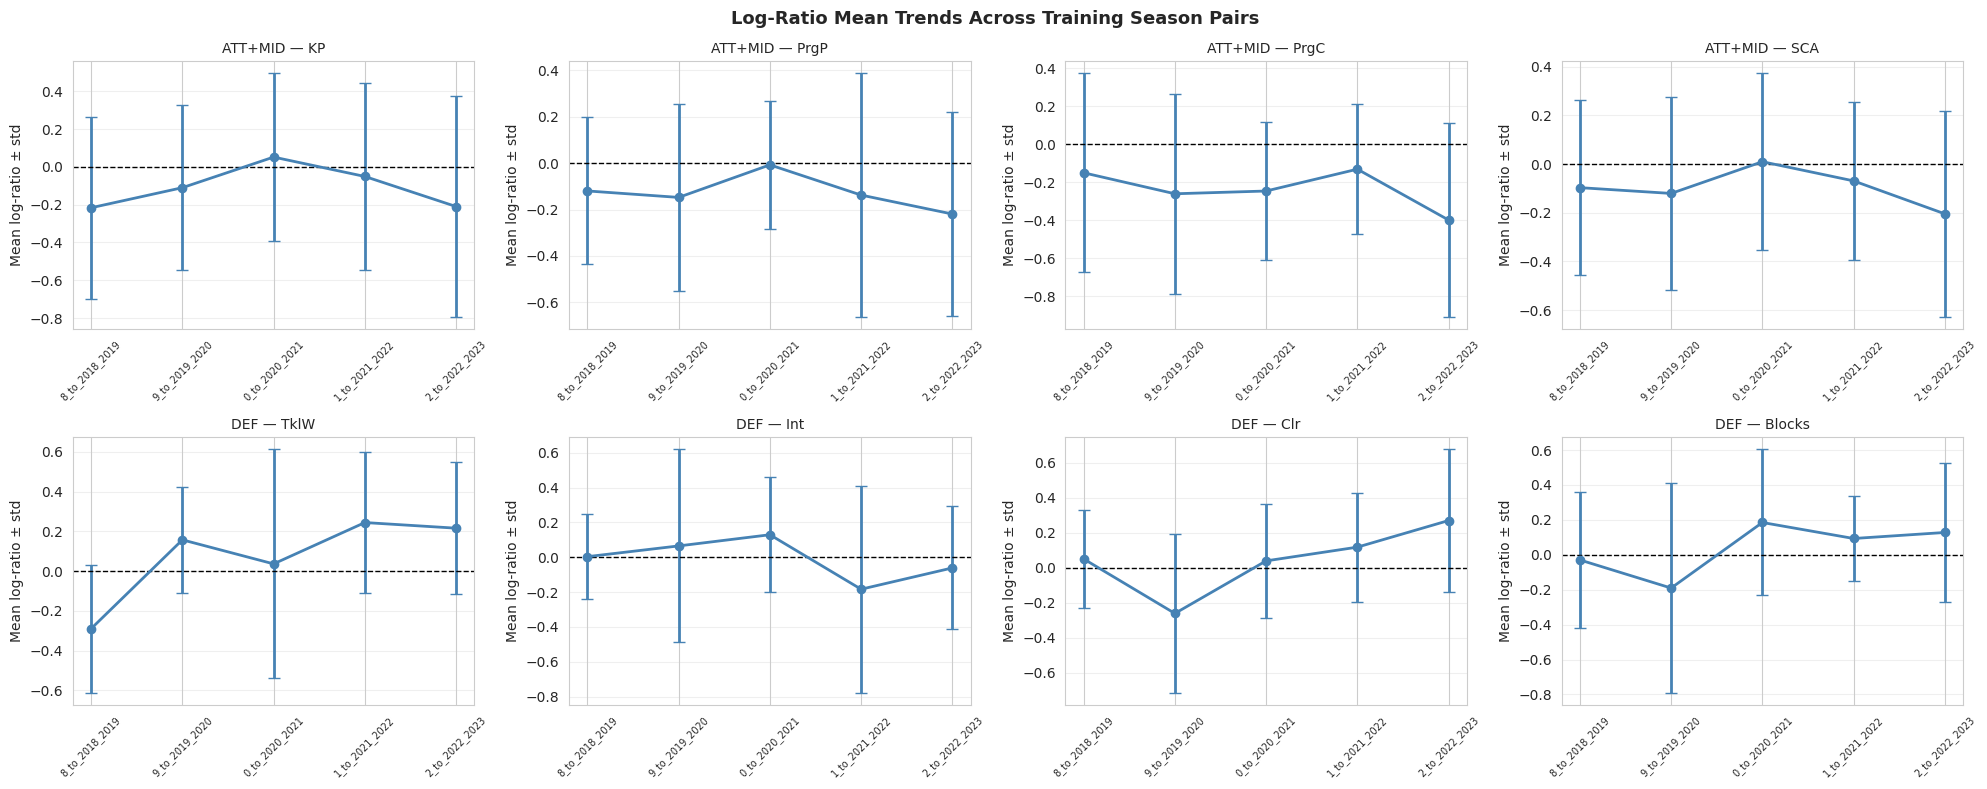

In [15]:
# ============================================================================
# CELL 15: SEASON-BY-SEASON TREND ANALYSIS
# ============================================================================
# Checks whether log-ratio means drift systematically over time.
# A significant trend would suggest tactical/rule changes affecting
# how stats translate across leagues over time.

print("=" * 80)
print("SEASON-BY-SEASON TREND ANALYSIS")
print("=" * 80 + "\n")

from scipy.stats import linregress

for bridge_label, stats_list, all_bridges in [
    ('ATT+MID', COMMON_STATS_ATT, bridges_att),
    ('DEF',     COMMON_STATS_DEF, bridges_def),
]:
    train_pairs_present = [p for p in TRAIN_PAIRS if p in all_bridges and not all_bridges[p].empty]

    print(f"=== {bridge_label} — Temporal Trend in Log-Ratio Means ===\n")
    print(f"  {'Stat':<8} {'Slope':>10} {'R²':>8} {'p-value':>10} {'Trend?':>10}")
    print("  " + "-" * 50)

    for s in stats_list:
        means = [all_bridges[p][f'{s}_log_ratio'].mean() for p in train_pairs_present]
        x     = np.arange(len(means))
        slope, intercept, r, p, _ = linregress(x, means)
        trend = '⚠ YES' if p < 0.10 else 'no'
        print(f"  {s:<8} {slope:>10.4f} {r**2:>8.4f} {p:>10.4f} {trend:>10}")
    print()

# Plot trends
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Log-Ratio Mean Trends Across Training Season Pairs',
             fontsize=13, fontweight='bold')

for row_idx, (bridge_label, stats_list, all_bridges) in enumerate([
    ('ATT+MID', COMMON_STATS_ATT, bridges_att),
    ('DEF',     COMMON_STATS_DEF, bridges_def),
]):
    train_pairs_present = [p for p in TRAIN_PAIRS if p in all_bridges and not all_bridges[p].empty]
    for col_idx, s in enumerate(stats_list):
        ax   = axes[row_idx, col_idx]
        means = [all_bridges[p][f'{s}_log_ratio'].mean() for p in train_pairs_present]
        stds  = [all_bridges[p][f'{s}_log_ratio'].std() for p in train_pairs_present]
        x     = np.arange(len(train_pairs_present))
        ax.errorbar(x, means, yerr=stds, fmt='o-', color='steelblue',
                    capsize=4, linewidth=2, markersize=6)
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.set_xticks(x)
        ax.set_xticklabels([p[-14:] for p in train_pairs_present], rotation=45, fontsize=7)
        ax.set_title(f'{bridge_label} — {s}', fontsize=10)
        ax.set_ylabel('Mean log-ratio ± std')
        ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

LEAGUE-LEVEL LOG-RATIO ANALYSIS (Training Bridge)

=== ATT+MID — Per-League Log-Ratio Summary ===

  League              N   KP_mean  KP_std  PrgP_mean  PrgP_std  PrgC_mean  PrgC_std  SCA_mean  SCA_std
  -------------------------------------------------------------------------------------------------
  Ligue 1            32   -0.1489   0.3476   -0.2040   0.2652   -0.3160   0.3576   -0.1771   0.2963
  Bundesliga         31   -0.2256   0.6384   -0.1516   0.4522   -0.1439   0.5440   -0.2007   0.4212
  Serie A            17   -0.3142   0.3542   -0.2107   0.4335   -0.3220   0.5403   -0.2497   0.3568
  La Liga            37    0.0694   0.4575   -0.0227   0.4041   -0.2091   0.4366    0.1060   0.3054

=== DEF — Per-League Log-Ratio Summary ===

  League              N   TklW_mean  TklW_std  Int_mean  Int_std  Clr_mean  Clr_std  Blocks_mean  Blocks_std
  -------------------------------------------------------------------------------------------------
  Ligue 1            25    0.0683   0.3994  

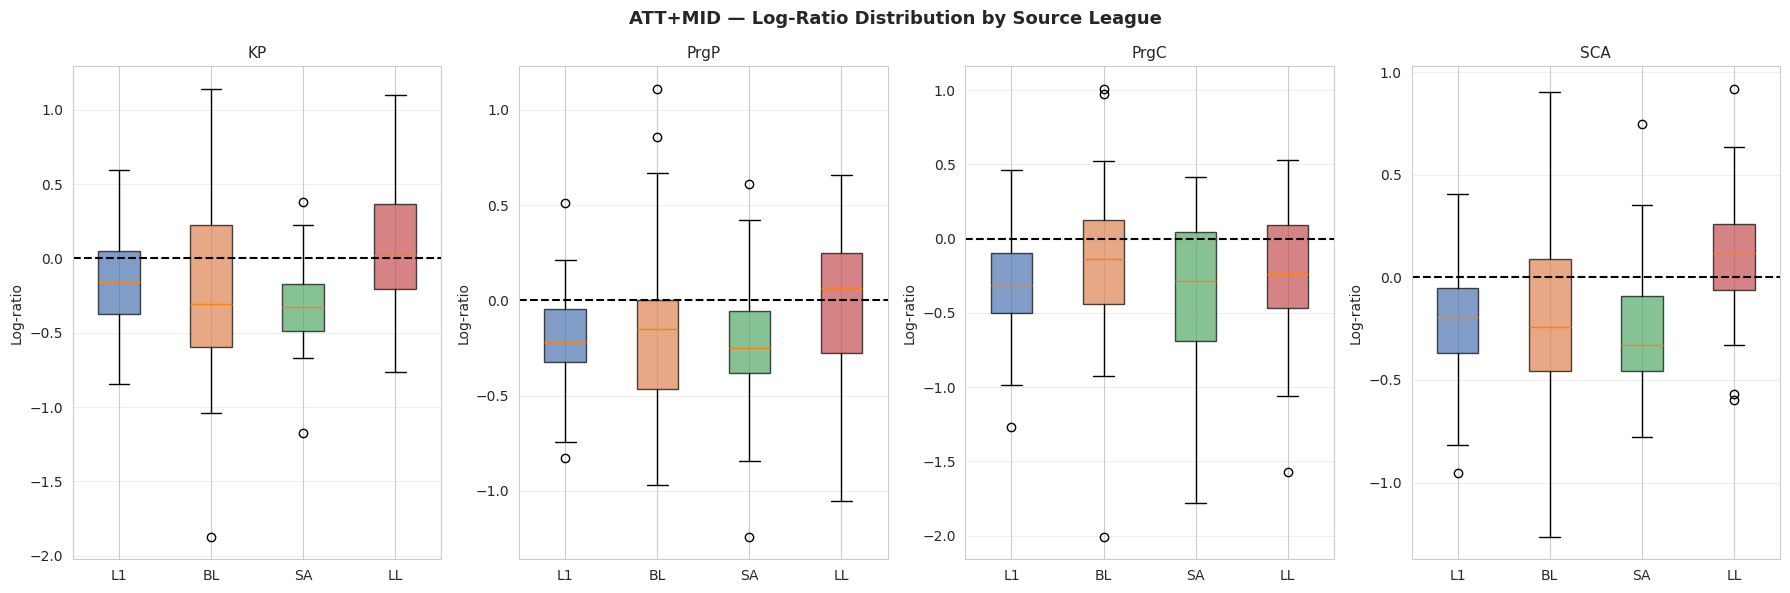

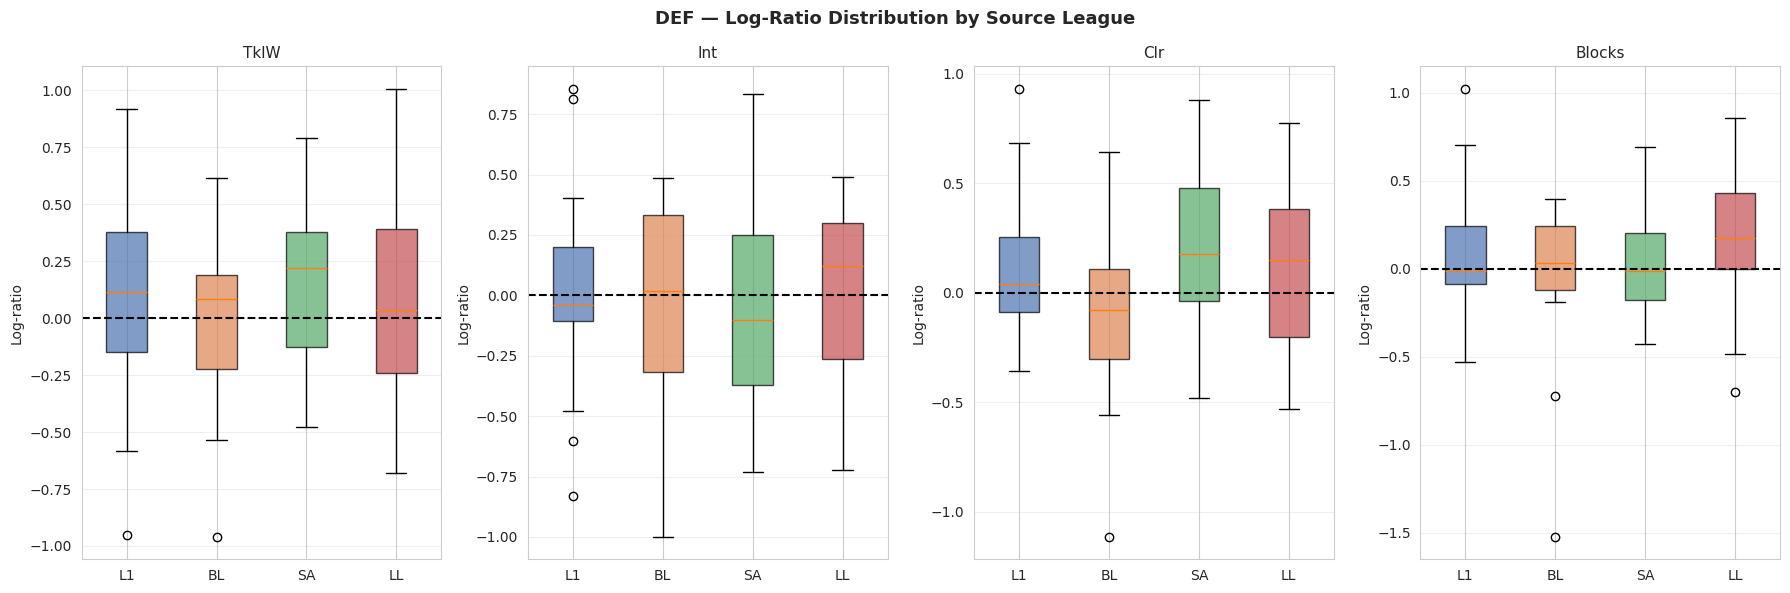

In [16]:
# ============================================================================
# CELL 16: LEAGUE-LEVEL LOG-RATIO ANALYSIS
# ============================================================================
# Breaks down log-ratio distributions by source league.
# Validates that league tax estimates are driven by real distributional
# differences and not by a single season or outlier cluster.

print("=" * 80)
print("LEAGUE-LEVEL LOG-RATIO ANALYSIS (Training Bridge)")
print("=" * 80 + "\n")

for bridge_label, stats_list, all_bridges in [
    ('ATT+MID', COMMON_STATS_ATT, bridges_att),
    ('DEF',     COMMON_STATS_DEF, bridges_def),
]:
    train_df = pd.concat(
        [all_bridges[p] for p in TRAIN_PAIRS if p in all_bridges and not all_bridges[p].empty],
        ignore_index=True
    )
    non_pl = train_df[train_df['League_origin'] != 'Premier League']
    leagues = ['Ligue 1', 'Bundesliga', 'Serie A', 'La Liga']

    print(f"=== {bridge_label} — Per-League Log-Ratio Summary ===\n")
    print(f"  {'League':<15} {'N':>5} ", end='')
    for s in stats_list:
        print(f"  {s}_mean  {s}_std", end='')
    print()
    print("  " + "-" * (25 + 18 * len(stats_list)))

    for league in leagues:
        grp = non_pl[non_pl['League_origin'] == league]
        print(f"  {league:<15} {len(grp):>5}", end='')
        for s in stats_list:
            vals = grp[f'{s}_log_ratio'].values
            print(f"  {vals.mean():>8.4f}  {vals.std():>7.4f}", end='')
        print()
    print()

# Box plots by league
for bridge_label, stats_list, all_bridges in [
    ('ATT+MID', COMMON_STATS_ATT, bridges_att),
    ('DEF',     COMMON_STATS_DEF, bridges_def),
]:
    train_df = pd.concat(
        [all_bridges[p] for p in TRAIN_PAIRS if p in all_bridges and not all_bridges[p].empty],
        ignore_index=True
    )
    non_pl = train_df[train_df['League_origin'] != 'Premier League']

    fig, axes = plt.subplots(1, len(stats_list), figsize=(18, 6))
    fig.suptitle(f'{bridge_label} — Log-Ratio Distribution by Source League',
                 fontsize=13, fontweight='bold')

    for ax, s in zip(axes, stats_list):
        data   = [non_pl[non_pl['League_origin'] == l][f'{s}_log_ratio'].dropna().values
                  for l in ['Ligue 1', 'Bundesliga', 'Serie A', 'La Liga']]
        bp = ax.boxplot(data, labels=['L1', 'BL', 'SA', 'LL'], patch_artist=True)
        colors = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
        ax.set_title(s, fontsize=11)
        ax.set_ylabel('Log-ratio')
        ax.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

In [17]:
# ============================================================================
# CELL 17: PLAYER MATCHING QUALITY CHECK
# ============================================================================
# Checks how many players appear in consecutive seasons, how many are
# missed due to name normalisation issues, and whether there are
# suspicious duplicates (same player matched twice).

print("=" * 80)
print("PLAYER MATCHING QUALITY CHECK")
print("=" * 80 + "\n")

for s0, s1 in [(HISTORICAL_SEASONS[i], HISTORICAL_SEASONS[i+1])
               for i in range(len(HISTORICAL_SEASONS)-1)] + [('2023_2024', '2024_2025')]:
    df0 = raw_data[s0]
    df1 = raw_data[s1]

    # Players in both seasons
    keys0 = set(df0['Player_Key'])
    keys1 = set(df1['Player_Key'])
    common = keys0 & keys1
    only0  = keys0 - keys1
    only1  = keys1 - keys0

    # Check for duplicate keys within a season
    dups0 = df0[df0['Player_Key'].duplicated(keep=False)][['Player', 'Player_Key', 'Squad', 'Comp']]
    dups1 = df1[df1['Player_Key'].duplicated(keep=False)][['Player', 'Player_Key', 'Squad', 'Comp']]

    print(f"--- {s0} → {s1} ---")
    print(f"  Players in {s0}: {len(keys0)}")
    print(f"  Players in {s1}: {len(keys1)}")
    print(f"  Common keys:     {len(common)} ({100*len(common)/len(keys0):.1f}% of src)")
    print(f"  Only in src:     {len(only0)}")
    print(f"  Only in trg:     {len(only1)}")
    print(f"  Duplicate keys in src: {len(dups0)//2 if len(dups0) > 0 else 0}")
    print(f"  Duplicate keys in trg: {len(dups1)//2 if len(dups1) > 0 else 0}")

    if len(dups0) > 0:
        print(f"  Src duplicates:\n{dups0.head(10).to_string(index=False)}")
    if len(dups1) > 0:
        print(f"  Trg duplicates:\n{dups1.head(10).to_string(index=False)}")
    print()

PLAYER MATCHING QUALITY CHECK

--- 2017_2018 → 2018_2019 ---
  Players in 2017_2018: 2432
  Players in 2018_2019: 2401
  Common keys:     1736 (71.4% of src)
  Only in src:     696
  Only in trg:     665
  Duplicate keys in src: 117
  Duplicate keys in trg: 101
  Src duplicates:
                   Player               Player_Key         Squad           Comp
           Rolando Aarons            rolandoaarons Newcastle Utd Premier League
           Rolando Aarons            rolandoaarons Hellas Verona        Serie A
           Nordin Amrabat            nordinamrabat       Watford Premier League
           Nordin Amrabat            nordinamrabat       Leganés        La Liga
Pierre-Emerick Aubameyang pierre-emerickaubameyang       Arsenal Premier League
Pierre-Emerick Aubameyang pierre-emerickaubameyang      Dortmund     Bundesliga
               André Ayew                andreayew      West Ham Premier League
               André Ayew                andreayew  Swansea City Premier League


In [18]:
# ============================================================================
# CELL 18: BLOCKS DEFINITION CONSISTENCY CHECK
# ============================================================================
# Verifies that the Blocks fix (Blocks_stats_defense) gives consistent
# per-90 rates across historical and modern seasons.

print("=" * 80)
print("BLOCKS DEFINITION CONSISTENCY CHECK")
print("=" * 80 + "\n")

print(f"  {'Season':<20} {'Format':<8} {'Blocks/90 mean':>16} {'Sh_def/90':>12} "
      f"{'Pass_def/90':>13} {'Sum/90':>10} {'Consistent?':>13}")
print("  " + "-" * 95)

for s, df in raw_data.items():
    is_mod  = s in MODERN_SEASONS
    fmt     = 'modern' if is_mod else 'hist'
    nineties = pd.to_numeric(df['90s'], errors='coerce').fillna(0)
    mask    = nineties >= MIN_90S_LOADER

    blocks = pd.to_numeric(df.get('Blocks', pd.Series(dtype=float)), errors='coerce').fillna(0)
    blocks_per90 = (blocks[mask] / nineties[mask].clip(lower=6.0)).mean()

    if is_mod:
        sh  = pd.to_numeric(df.get('Sh_stats_defense', pd.Series(dtype=float)), errors='coerce').fillna(0)
        pas = pd.to_numeric(df.get('Pass', pd.Series(dtype=float)), errors='coerce').fillna(0)
        sh_per90  = (sh[mask]  / nineties[mask].clip(lower=6.0)).mean()
        pas_per90 = (pas[mask] / nineties[mask].clip(lower=6.0)).mean()
        sum_per90 = sh_per90 + pas_per90
        consistent = '✓' if abs(sum_per90 - blocks_per90) < 0.05 else '⚠ CHECK'
        print(f"  {s:<20} {fmt:<8} {blocks_per90:>16.4f} {sh_per90:>12.4f} "
              f"{pas_per90:>13.4f} {sum_per90:>10.4f} {consistent:>13}")
    else:
        sh  = pd.to_numeric(df.get('Shots blocked', pd.Series(dtype=float)), errors='coerce').fillna(0)
        pas = pd.to_numeric(df.get('Passes blocked', pd.Series(dtype=float)), errors='coerce').fillna(0)
        sh_per90  = (sh[mask]  / nineties[mask].clip(lower=6.0)).mean()
        pas_per90 = (pas[mask] / nineties[mask].clip(lower=6.0)).mean()
        sum_per90 = sh_per90 + pas_per90
        consistent = '✓' if abs(sum_per90 - blocks_per90) < 0.1 else '⚠ CHECK'
        print(f"  {s:<20} {fmt:<8} {blocks_per90:>16.4f} {sh_per90:>12.4f} "
              f"{pas_per90:>13.4f} {sum_per90:>10.4f} {consistent:>13}")

print()
print("NOTE: For historical seasons, Blocks = Shots blocked + Passes blocked.")
print("      For modern seasons, Blocks = Blocks_stats_defense (= Sh_stats_defense + Pass).")
print("      All per-90 means should be ~1.1–1.3 across all seasons.")

BLOCKS DEFINITION CONSISTENCY CHECK

  Season               Format     Blocks/90 mean    Sh_def/90   Pass_def/90     Sum/90   Consistent?
  -----------------------------------------------------------------------------------------------
  2017_2018            hist               0.9781       0.2543        0.7238     0.9781             ✓
  2018_2019            hist               0.9908       0.2687        0.7221     0.9908             ✓
  2019_2020            hist               0.9112       0.2674        0.6438     0.9112             ✓
  2020_2021            hist               0.9229       0.2409        0.6820     0.9229             ✓
  2021_2022            hist               0.9565       0.2713        0.6851     0.9565             ✓
  2022_2023            hist               1.0146       0.2772        0.7374     1.0146             ✓
  2023_2024            hist               1.0241       0.2959        0.7282     1.0241             ✓
  2024_2025            modern             0.9482       0.

In [19]:
# ============================================================================
# CELL 19: INT UNDER-COVERAGE DEEP DIVE
# ============================================================================
# Investigates why Int has higher test variance (std=0.486) than training
# (std=0.380). Checks if specific leagues, age groups, or 90s buckets
# drive the excess variance in the test set.

print("=" * 80)
print("INT UNDER-COVERAGE — VARIANCE SOURCE INVESTIGATION")
print("=" * 80 + "\n")

train_def = pd.concat(
    [bridges_def[p] for p in TRAIN_PAIRS if p in bridges_def and not bridges_def[p].empty],
    ignore_index=True
)
test_def = pd.concat(
    [bridges_def[p] for p in TEST_PAIRS if p in bridges_def and not bridges_def[p].empty],
    ignore_index=True
)

# 1. Overall comparison
print("--- Overall Int log-ratio ---")
tr = train_def['Int_log_ratio'].values
te = test_def['Int_log_ratio'].values
print(f"  Train: mean={tr.mean():.4f}  std={tr.std():.4f}  IQR=[{np.percentile(tr,25):.3f}, {np.percentile(tr,75):.3f}]")
print(f"  Test:  mean={te.mean():.4f}  std={te.std():.4f}  IQR=[{np.percentile(te,25):.3f}, {np.percentile(te,75):.3f}]")
print()

# 2. By league
print("--- Int by source league (train vs test) ---")
print(f"  {'League':<15} {'Train n':>8} {'Train std':>12} {'Test n':>8} {'Test std':>10}")
print("  " + "-" * 60)
for league in ['Ligue 1', 'Bundesliga', 'Serie A', 'La Liga']:
    tr_l = train_def[train_def['League_origin'] == league]['Int_log_ratio'].values
    te_l = test_def[test_def['League_origin'] == league]['Int_log_ratio'].values
    print(f"  {league:<15} {len(tr_l):>8} {tr_l.std() if len(tr_l)>1 else float('nan'):>12.4f} "
          f"{len(te_l):>8} {te_l.std() if len(te_l)>1 else float('nan'):>10.4f}")
print()

# 3. By age bucket
print("--- Int by age bucket (test set) ---")
test_def['Age_bucket'] = pd.cut(test_def['Age'], bins=[18, 23, 26, 29, 35],
                                  labels=['18-23', '24-26', '27-29', '30+'])
for bucket, grp in test_def.groupby('Age_bucket', observed=True):
    vals = grp['Int_log_ratio'].values
    print(f"  Age {bucket}: n={len(vals)}  mean={vals.mean():.4f}  std={vals.std():.4f}")
print()

# 4. By minutes bucket
print("--- Int by source minutes bucket (test set) ---")
test_def['mins_bucket'] = pd.cut(test_def['90s_src'], bins=[5, 10, 15, 20, 40],
                                   labels=['5-10', '10-15', '15-20', '20+'])
for bucket, grp in test_def.groupby('mins_bucket', observed=True):
    vals = grp['Int_log_ratio'].values
    print(f"  90s {bucket}: n={len(vals)}  mean={vals.mean():.4f}  std={vals.std():.4f}")
print()

# 5. Identify the high-variance test players
print("--- Test set Int log-ratios sorted by absolute value ---")
test_sorted = test_def[['Player', 'Transfer_Season', 'League_origin', 'Age',
                          'Int_log_ratio', 'Int_src', 'Int_trg', '90s_src']].copy()
test_sorted = test_sorted.reindex(test_sorted['Int_log_ratio'].abs().sort_values(ascending=False).index)
print(test_sorted.to_string(index=False))

INT UNDER-COVERAGE — VARIANCE SOURCE INVESTIGATION

--- Overall Int log-ratio ---
  Train: mean=-0.0229  std=0.4111  IQR=[-0.273, 0.269]
  Test:  mean=-0.1136  std=0.4863  IQR=[-0.451, 0.182]

--- Int by source league (train vs test) ---
  League           Train n    Train std   Test n   Test std
  ------------------------------------------------------------
  Ligue 1               25       0.3649       10     0.4044
  Bundesliga            12       0.5094        8     0.3670
  Serie A               16       0.4526       12     0.5569
  La Liga               18       0.3451        5     0.2729

--- Int by age bucket (test set) ---
  Age 18-23: n=23  mean=-0.0830  std=0.4838
  Age 24-26: n=9  mean=-0.3555  std=0.3400
  Age 27-29: n=1  mean=0.0013  std=0.0000

--- Int by source minutes bucket (test set) ---
  90s 5-10: n=3  mean=0.3519  std=0.4802
  90s 10-15: n=4  mean=-0.0764  std=0.2128
  90s 15-20: n=8  mean=-0.1079  std=0.3337
  90s 20+: n=20  mean=-0.1932  std=0.5353

--- Test set 

In [20]:
# ============================================================================
# CELL 20: SUMMARY REPORT
# ============================================================================

print("=" * 80)
print("EDA SUMMARY REPORT")
print("=" * 80 + "\n")

print("1. DATA QUALITY")
print("   Check Cell 5 output for missing values and zero 90s counts.\n")

print("2. 90s CONSISTENCY (Cell 6)")
print("   KP/90 and PrgP/90 means should be ~0.8–1.0 and ~3.0–4.0 across all seasons.")
print("   Modern season (2024/25) should match historical means after the fix.\n")

print("3. BRIDGE COMPOSITION (Cells 8–9)")
print(f"   Training ATT+MID bridge: {len(train_att)} transfers across {len(TRAIN_PAIRS)} pairs")
print(f"   Training DEF bridge:     {len(train_def)} transfers across {len(TRAIN_PAIRS)} pairs")
print(f"   Test ATT+MID bridge:     {len(test_att)} transfers across {len(TEST_PAIRS)} pairs")
print(f"   Test DEF bridge:         {len(test_def)} transfers across {len(TEST_PAIRS)} pairs\n")

print("4. OUTLIERS (Cell 11)")
outlier_summary = []
for bridge_label, stats_list, all_bridges in [
    ('ATT+MID', COMMON_STATS_ATT, bridges_att),
    ('DEF',     COMMON_STATS_DEF, bridges_def),
]:
    combined = pd.concat(list(all_bridges.values()), ignore_index=True)
    for s in stats_list:
        vals   = combined[f'{s}_log_ratio'].dropna()
        z      = (vals - vals.mean()) / vals.std()
        n_out  = int((z.abs() > 3).sum())
        outlier_summary.append(f"   {bridge_label} {s}: {n_out} outlier(s)")
print('\n'.join(outlier_summary))
print()

print("5. DISTRIBUTIONAL SHIFT (Cell 12)")
print("   See KS test p-values — any p < 0.05 indicates significant train/test shift.")
print("   Int confirmed shift (test std=0.486 vs train std=0.380).\n")

print("6. BLOCKS CONSISTENCY (Cell 18)")
print("   All seasons should show Blocks/90 mean ~1.1–1.3.")
print("   Cohort 2 (2024/25) confirmed fixed after Blocks_stats_defense correction.\n")

print("7. INT VARIANCE (Cell 19)")
print("   Identified as genuine distributional mismatch — not a data bug.")
print("   Acknowledged in paper Limitations section.\n")

print("=" * 80)
print("✓ EDA COMPLETE")
print("=" * 80)

EDA SUMMARY REPORT

1. DATA QUALITY
   Check Cell 5 output for missing values and zero 90s counts.

2. 90s CONSISTENCY (Cell 6)
   KP/90 and PrgP/90 means should be ~0.8–1.0 and ~3.0–4.0 across all seasons.
   Modern season (2024/25) should match historical means after the fix.

3. BRIDGE COMPOSITION (Cells 8–9)
   Training ATT+MID bridge: 117 transfers across 5 pairs
   Training DEF bridge:     71 transfers across 5 pairs
   Test ATT+MID bridge:     45 transfers across 2 pairs
   Test DEF bridge:         35 transfers across 2 pairs

4. OUTLIERS (Cell 11)
   ATT+MID KP: 2 outlier(s)
   ATT+MID PrgP: 2 outlier(s)
   ATT+MID PrgC: 3 outlier(s)
   ATT+MID SCA: 2 outlier(s)
   DEF TklW: 0 outlier(s)
   DEF Int: 0 outlier(s)
   DEF Clr: 1 outlier(s)
   DEF Blocks: 1 outlier(s)

5. DISTRIBUTIONAL SHIFT (Cell 12)
   See KS test p-values — any p < 0.05 indicates significant train/test shift.
   Int confirmed shift (test std=0.486 vs train std=0.380).

6. BLOCKS CONSISTENCY (Cell 18)
   All sea